## **Note**

This is the assignment for Module 4 of Introduction to Deep Learning.

More information can be found on https://github.com/minhleathvn/machine-learnin-theory-and-hands-on-practice-with-pythong-cu/tree/main/3-introduction-to-deep-learning-boulder/module-4

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/glove-6b-100-d/glove.6B.100d.txt
/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


# 1. Introduction: Problem and Data Description

## 1.1. Problem Statement:

The objective of the "Natural Language Processing with Disaster Tweets" Kaggle competition is to develop a machine learning model capable of classifying tweets as either genuine disaster-related messages or not. This task is crucial for organizations involved in disaster relief, as it enables them to rapidly identify and respond to real-time information during crises. By accurately filtering relevant tweets, these organizations can more efficiently allocate resources and provide timely assistance.

## 1.2. What is NLP in this Context?

Natural Language Processing (NLP) is a branch of artificial intelligence that focuses on enabling computers to understand, interpret, and generate human language. In the context of this project, NLP techniques are applied to process unstructured text data (tweets) to extract meaningful information and classify them. This involves tasks such as text preprocessing, feature extraction from textual content, and building models that can learn patterns within human language to make accurate predictions.

## 1.3. Dataset Description:

The dataset for this competition consists of three primary files: **train.csv**, **test.csv**, and **sample_submission.csv**.

* Size and Dimensions:

    * **train.csv:** Contains the training data, which will be used to train the machine learning model.

    * **test.csv:** Contains the test data, on which the trained model will make predictions. (The exact number of rows and columns for both will be determined during the Exploratory Data Analysis phase.)

* Structure/Columns:

    * **id:** A unique identifier for each tweet.

    * **keyword:** A specific keyword extracted from the tweet. This column may have missing values.

    * **location:** The geographical location from which the tweet was sent. This column may also have missing values.

    * **text:** The main content of the tweet, serving as the primary feature for classification.

    * **target:** This is the target variable, present only in the **train.csv** file. It indicates whether a tweet is about a real disaster (*1*) or not (*0*).

### Train.csv

* **Size:** 987.71 kB.

* **Columns:** It has 5 columns: id, keyword, location, text, and target.

* **Data Overview:**

    * **id:** Ranges from 1 to 10.9k.

    * **keyword:** Has 222 unique values, with 33% being null. "USA" is present in 1% of the entries, and "Other" makes up 65%.

    * **location:** Has 7503 unique values.

    * **target:** This is the prediction variable, with 4,342 entries for *0* (not a disaster) and 3,271 entries for *1* (disaster).

* There are some rows from train.csv, showing examples of tweets and their corresponding target values. For instance, "*Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all*" has a target of *1*, while "*What's up man?*" has a target of *0*.

# 2. Exploratory Data Analysis (EDA): Inspect, Visualize, and Clean

## 2.1. Initial Data Inspection:

Load train.csv and test.csv into Pandas DataFrames.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load train.csv and test.csv into Pandas DataFrames
try:
    train_df = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
    test_df = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')
    sample_submission_df = pd.read_csv('/kaggle/input/nlp-getting-started/sample_submission.csv') # It's good practice to load this too
except FileNotFoundError:
    print("Ensure the dataset files are in the correct directory, typically '/kaggle/input/nlp-getting-started/' in Kaggle notebooks.")
    # Fallback for local testing if needed, though not directly applicable to Kaggle
    # train_df = pd.read_csv('train.csv')
    # test_df = pd.read_csv('test.csv')
    # sample_submission_df = pd.read_csv('sample_submission.csv')

print("--- Train DataFrame Head ---")
print(train_df.head())
print("\n--- Test DataFrame Head ---")
print(test_df.head())

print("\n--- Train DataFrame Info ---")
train_df.info()
print("\n--- Test DataFrame Info ---")
test_df.info()

print("\n--- Missing values in Train DataFrame ---")
print(train_df.isnull().sum())
print("\n--- Missing values in Test DataFrame ---")
print(test_df.isnull().sum())

print("\n--- Data Types in Train DataFrame ---")
print(train_df.dtypes)
print("\n--- Data Types in Test DataFrame ---")
print(test_df.dtypes)

--- Train DataFrame Head ---
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  

--- Test DataFrame Head ---
   id keyword location                                               text
0   0     NaN      NaN                 Just happened a terrible car crash
1   2     NaN      NaN  Heard about #earthquake is different cities, s...
2   3     NaN      NaN  there is a forest fire at spot pond, geese are...
3   9     NaN      NaN           Apocalypse lighting. #Spokane #wildfires
4  11     NaN      NaN      Typhoon S

## 2.2. Visualizations for Understanding Data:

Generate plots to help us understand:

* Target Variable Distribution: Whether disaster and non-disaster tweets are balanced.

* Tweet Lengths: If character and word counts differ between disaster and non-disaster tweets.

* Word Frequencies: The most common words across all tweets, and specifically for disaster vs. non-disaster tweets (after cleaning and removing stop words). This highlights key vocabulary.

* Keyword & Location Analysis: The frequency of top keywords and locations, and how keywords correlate with disaster tweets.


--- 2.2. Visualizations for Understanding Data ---


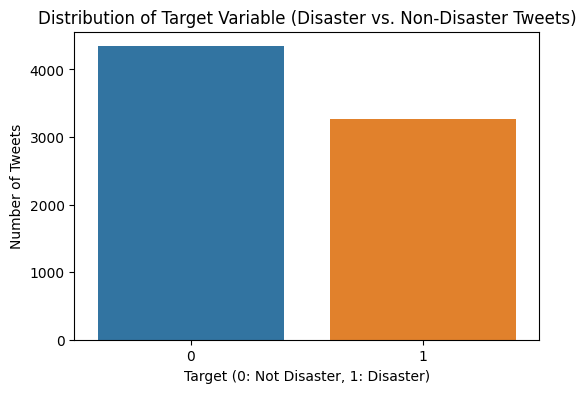

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


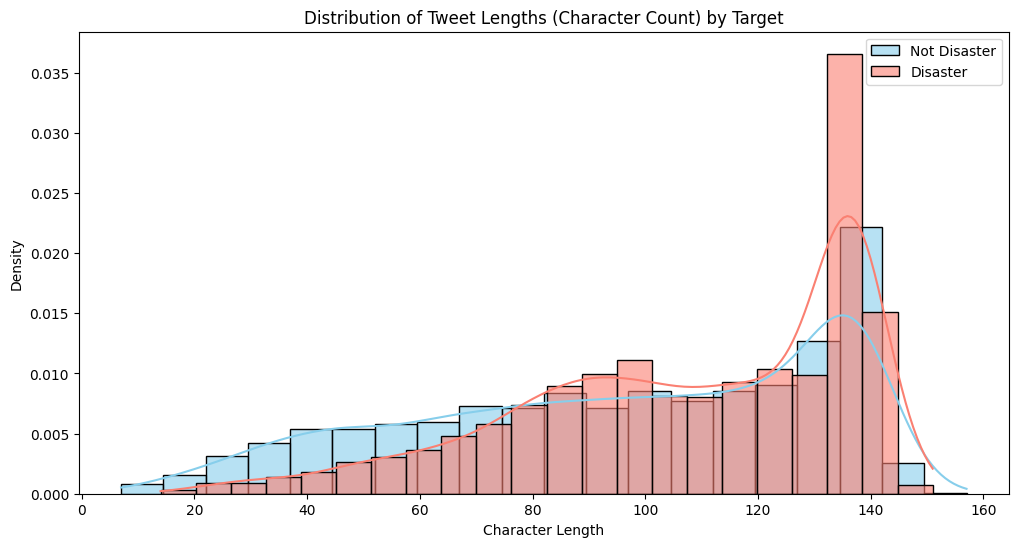

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


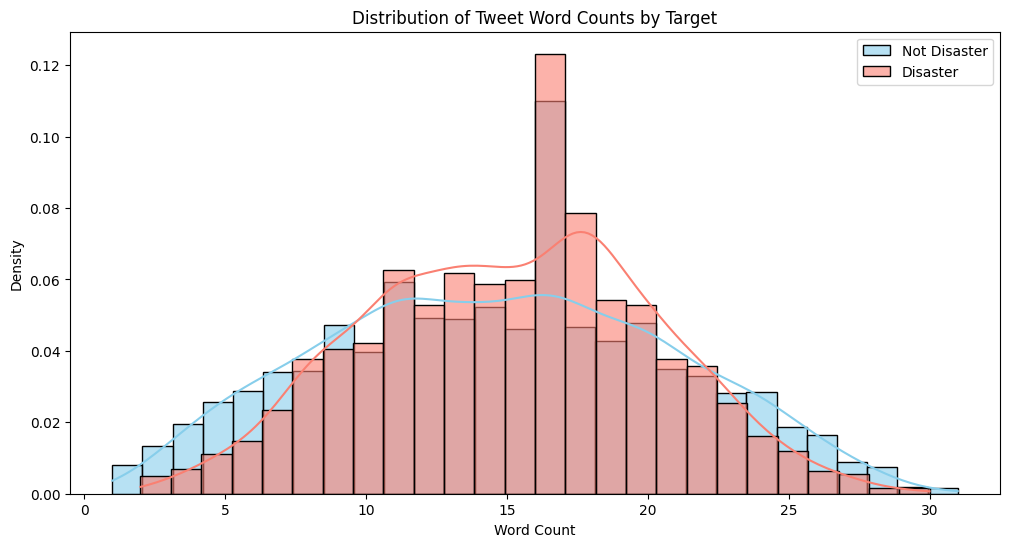

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


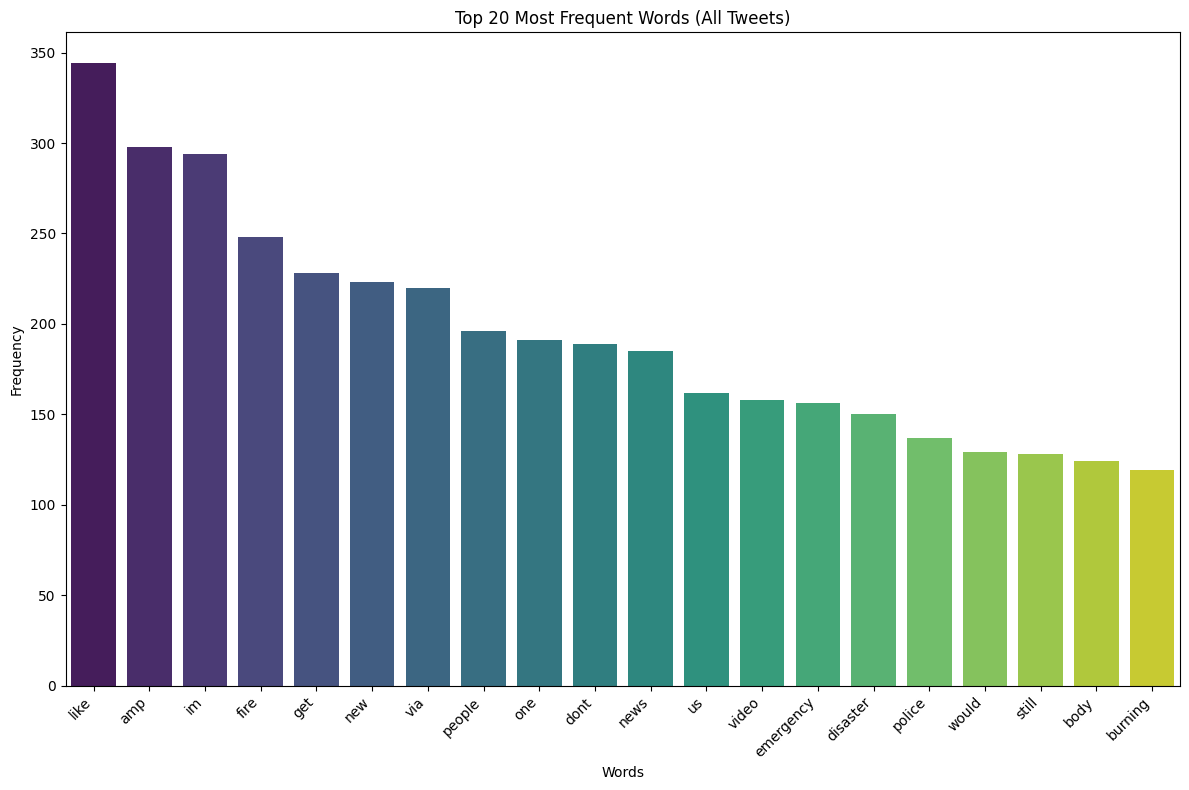

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


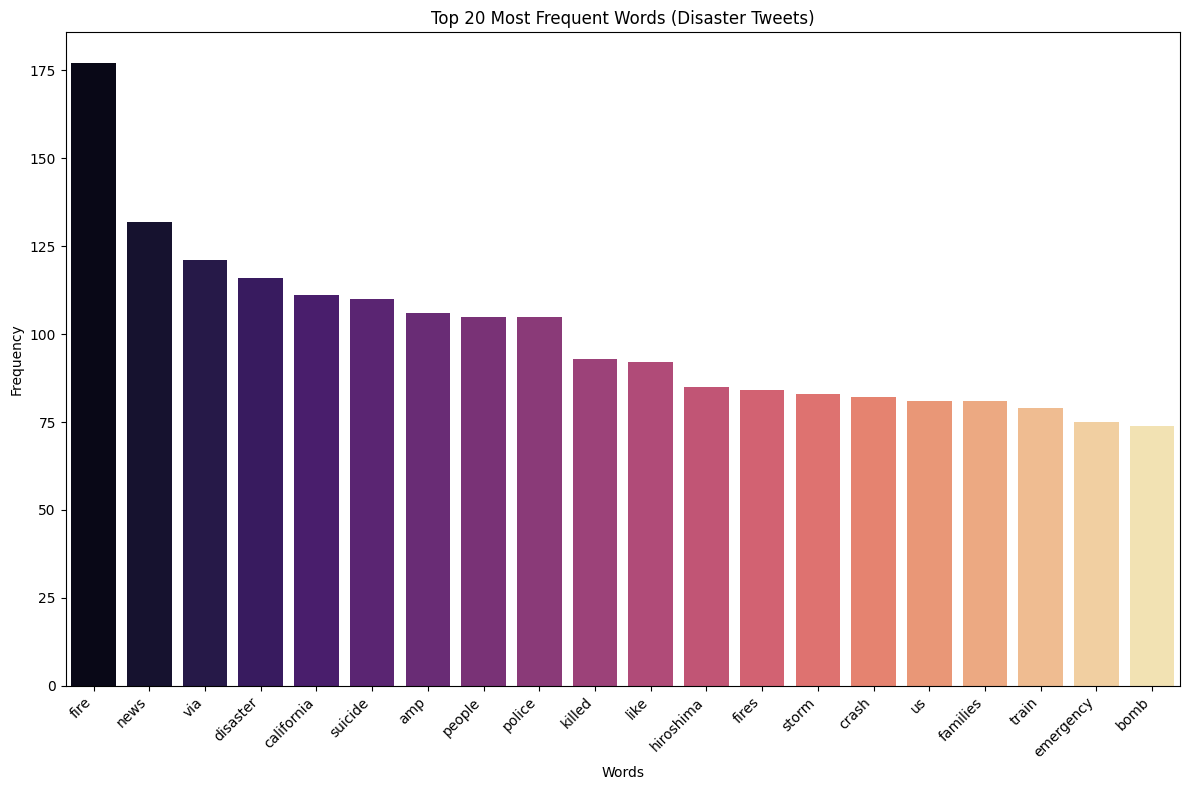

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


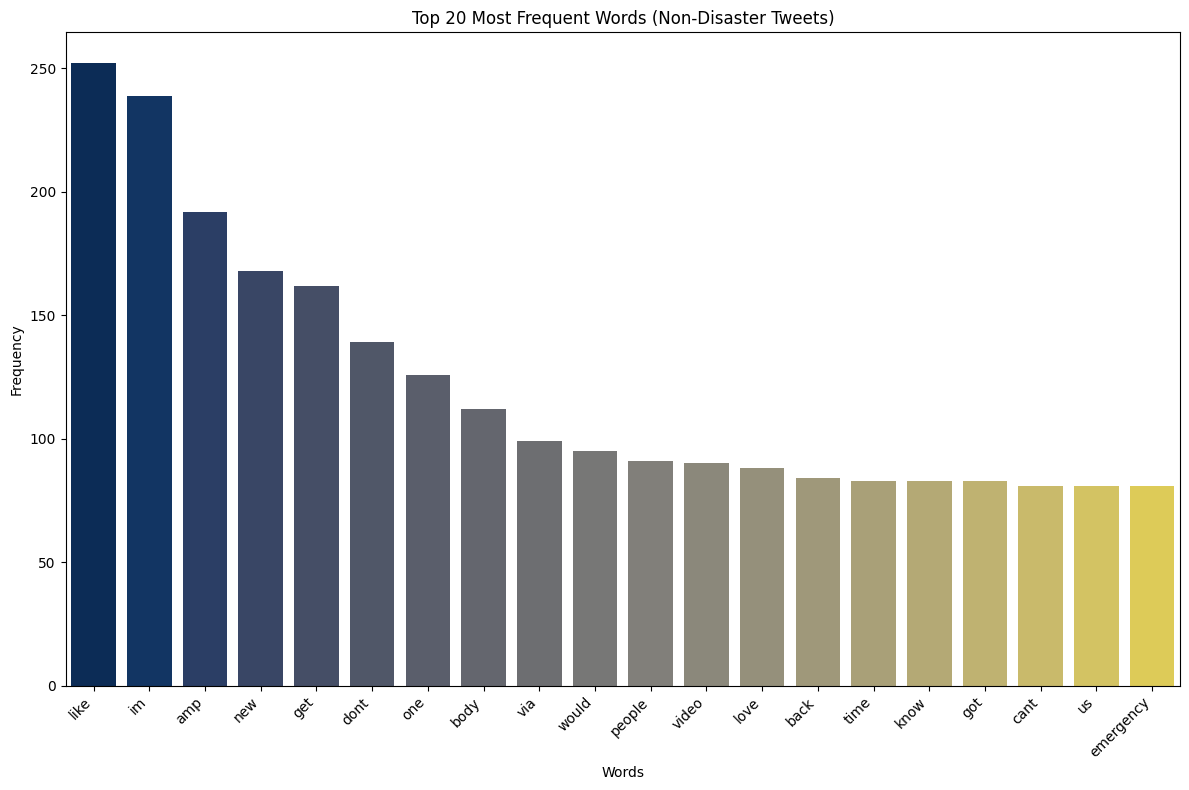


--- Keyword Analysis ---
Top 20 most frequent keywords in training data:
keyword
fatalities     45
deluge         42
armageddon     42
sinking        41
damage         41
harm           41
body%20bags    41
outbreak       40
evacuate       40
fear           40
collided       40
siren          40
twister        40
windstorm      40
sinkhole       39
sunk           39
hellfire       39
weapon         39
weapons        39
famine         39
Name: count, dtype: int64


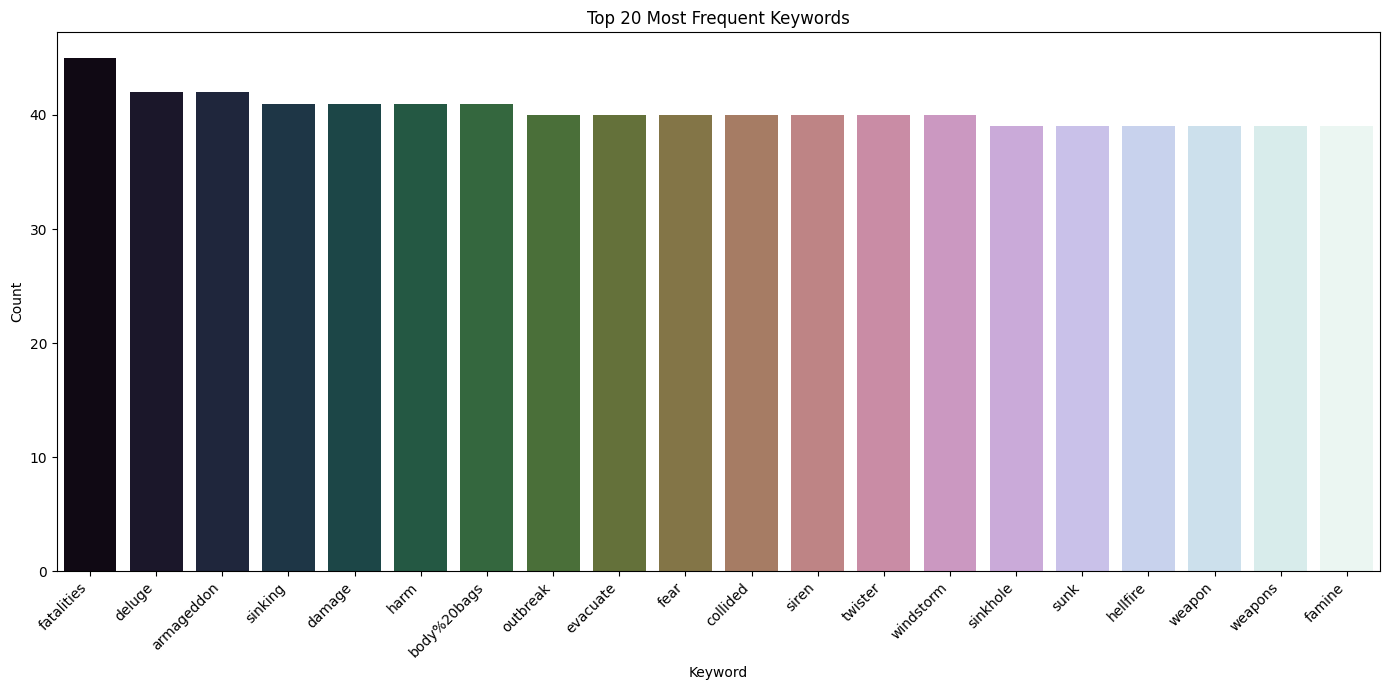


--- Proportion of Disaster Tweets per Top Keyword (Training Data) ---
keyword
debris                   1.000000
wreckage                 1.000000
derailment               1.000000
outbreak                 0.975000
oil%20spill              0.973684
typhoon                  0.973684
suicide%20bombing        0.969697
suicide%20bomber         0.967742
bombing                  0.931034
rescuers                 0.914286
suicide%20bomb           0.914286
nuclear%20disaster       0.911765
evacuated                0.888889
razed                    0.885714
wildfire                 0.878788
wild%20fires             0.870968
airplane%20accident      0.857143
mass%20murder            0.848485
buildings%20on%20fire    0.848485
forest%20fires           0.843750
Name: target, dtype: float64


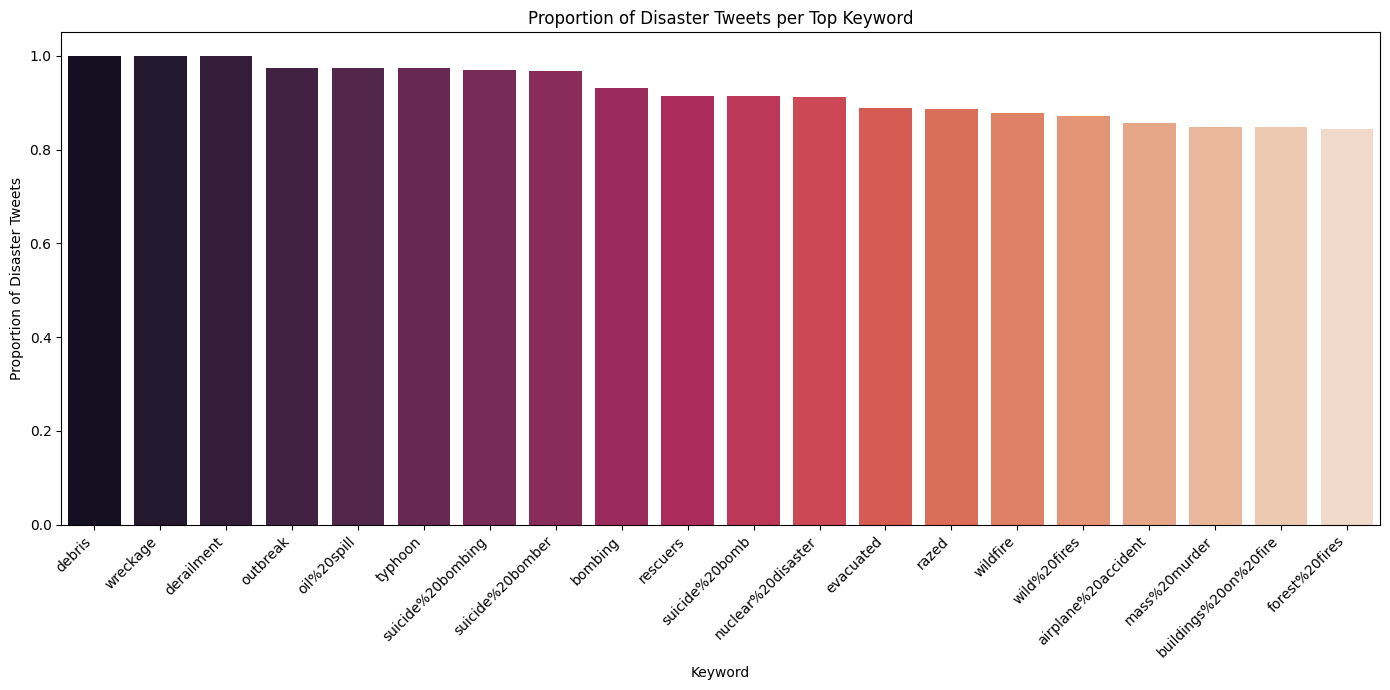


--- Location Analysis ---
Top 20 most frequent locations in training data:
location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Washington, DC      21
Kenya               20
Worldwide           19
Australia           18
Chicago, IL         18
California          17
Everywhere          15
New York, NY        15
California, USA     15
Florida             14
Name: count, dtype: int64


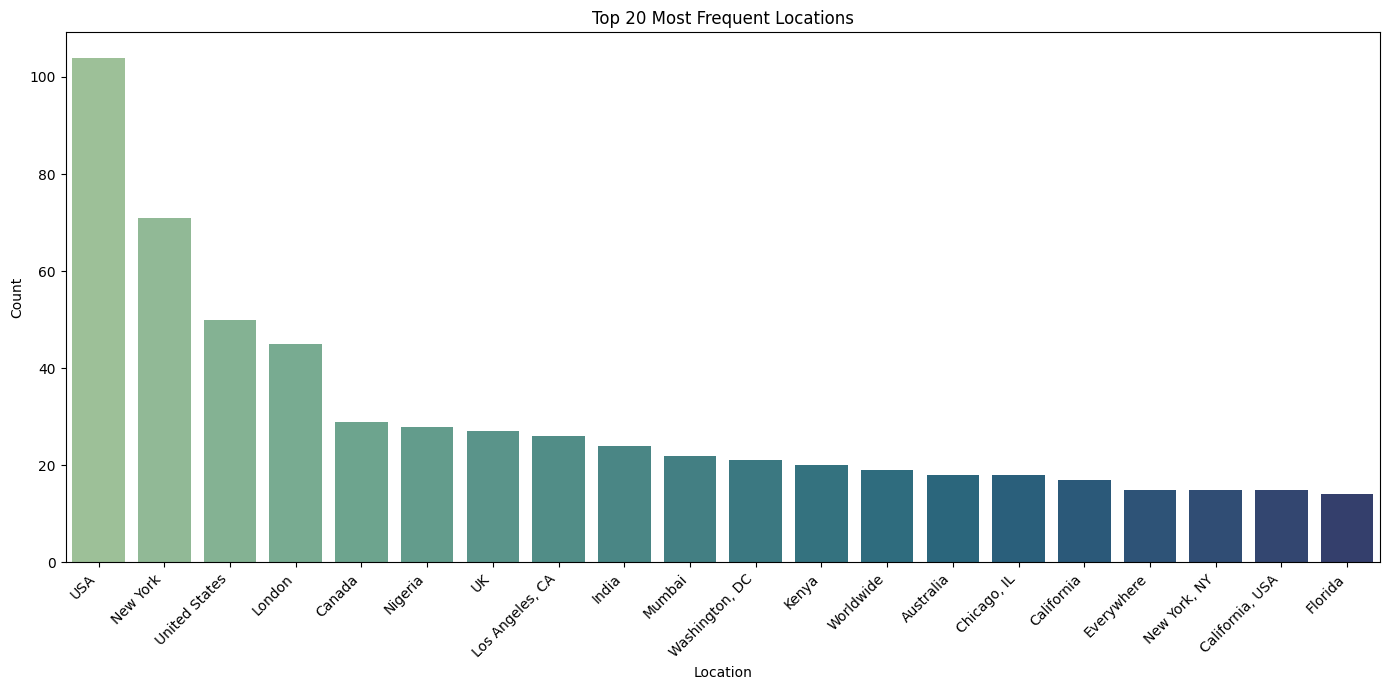

In [3]:
# --- 2.2. Visualizations for Understanding Data ---

print("\n--- 2.2. Visualizations for Understanding Data ---")

# 1. Distribution of Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=train_df)
plt.title('Distribution of Target Variable (Disaster vs. Non-Disaster Tweets)')
plt.xlabel('Target (0: Not Disaster, 1: Disaster)')
plt.ylabel('Number of Tweets')
plt.show()

# 2. Tweet Lengths (Character Count)
train_df['char_length'] = train_df['text'].apply(len)
test_df['char_length'] = test_df['text'].apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(train_df[train_df['target'] == 0]['char_length'], color='skyblue', label='Not Disaster', kde=True, stat='density', alpha=0.6)
sns.histplot(train_df[train_df['target'] == 1]['char_length'], color='salmon', label='Disaster', kde=True, stat='density', alpha=0.6)
plt.title('Distribution of Tweet Lengths (Character Count) by Target')
plt.xlabel('Character Length')
plt.ylabel('Density')
plt.legend()
plt.show()

# 3. Tweet Lengths (Word Count)
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))
test_df['word_count'] = test_df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.histplot(train_df[train_df['target'] == 0]['word_count'], color='skyblue', label='Not Disaster', kde=True, stat='density', alpha=0.6)
sns.histplot(train_df[train_df['target'] == 1]['word_count'], color='salmon', label='Disaster', kde=True, stat='density', alpha=0.6)
plt.title('Distribution of Tweet Word Counts by Target')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.legend()
plt.show()

# 4. Word Frequency Analysis (All Tweets)
from collections import Counter
import re
from nltk.corpus import stopwords
import string

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    import nltk
    nltk.download('stopwords')


def clean_text_for_word_cloud(text):
    text = text.lower() # Lowercase
    text = re.sub('\[.*?\]', '', text) # Remove text in square brackets
    text = re.sub('https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub('<.*?>+', '', text) # Remove HTML tags
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation
    text = re.sub('\n', '', text) # Remove newline characters
    text = re.sub('\w*\d\w*', '', text) # Remove words containing numbers
    return text

# Apply cleaning
train_df['cleaned_text'] = train_df['text'].apply(clean_text_for_word_cloud)

# Get all words from cleaned text
all_words = ' '.join(train_df['cleaned_text']).split()

# Remove stop words
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in all_words if word not in stop_words]

# Most common words
most_common_words = Counter(filtered_words).most_common(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=[word[0] for word in most_common_words], y=[word[1] for word in most_common_words], palette='viridis')
plt.title('Top 20 Most Frequent Words (All Tweets)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Word Frequency Analysis (Disaster vs. Non-Disaster Tweets)
disaster_tweets = train_df[train_df['target'] == 1]['cleaned_text']
non_disaster_tweets = train_df[train_df['target'] == 0]['cleaned_text']

# Most common words in disaster tweets
disaster_words = ' '.join(disaster_tweets).split()
filtered_disaster_words = [word for word in disaster_words if word not in stop_words]
most_common_disaster_words = Counter(filtered_disaster_words).most_common(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=[word[0] for word in most_common_disaster_words], y=[word[1] for word in most_common_disaster_words], palette='magma')
plt.title('Top 20 Most Frequent Words (Disaster Tweets)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Most common words in non-disaster tweets
non_disaster_words = ' '.join(non_disaster_tweets).split()
filtered_non_disaster_words = [word for word in non_disaster_words if word not in stop_words]
most_common_non_disaster_words = Counter(filtered_non_disaster_words).most_common(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=[word[0] for word in most_common_non_disaster_words], y=[word[1] for word in most_common_non_disaster_words], palette='cividis')
plt.title('Top 20 Most Frequent Words (Non-Disaster Tweets)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 6. Keyword Analysis
# Fill NaN keywords for better visualization if needed, or analyze NaN count
print("\n--- Keyword Analysis ---")
print("Top 20 most frequent keywords in training data:")
print(train_df['keyword'].value_counts().head(20))

plt.figure(figsize=(14, 7))
top_keywords = train_df['keyword'].value_counts().nlargest(20)
sns.barplot(x=top_keywords.index, y=top_keywords.values, palette='cubehelix')
plt.title('Top 20 Most Frequent Keywords')
plt.xlabel('Keyword')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Analyze correlation of top keywords with target (e.g., proportion of disaster tweets for each keyword)
print("\n--- Proportion of Disaster Tweets per Top Keyword (Training Data) ---")
keyword_target_proportion = train_df.groupby('keyword')['target'].mean().sort_values(ascending=False).head(20)
print(keyword_target_proportion)

plt.figure(figsize=(14, 7))
sns.barplot(x=keyword_target_proportion.index, y=keyword_target_proportion.values, palette='rocket')
plt.title('Proportion of Disaster Tweets per Top Keyword')
plt.xlabel('Keyword')
plt.ylabel('Proportion of Disaster Tweets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 7. Location Analysis (Top 20)
print("\n--- Location Analysis ---")
print("Top 20 most frequent locations in training data:")
print(train_df['location'].value_counts().head(20))

plt.figure(figsize=(14, 7))
top_locations = train_df['location'].value_counts().nlargest(20)
sns.barplot(x=top_locations.index, y=top_locations.values, palette='crest')
plt.title('Top 20 Most Frequent Locations')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2.3. Data Cleaning Procedures:

### Handling Missing Values:
* **Strategy:** For both keyword and location columns, we've chosen to impute missing values with the string 'unknown'.

* **Justification:**

    * *keyword:* Missing keywords might indicate that no specific keyword was extracted or that the tweet simply didn't contain one relevant to the competition's predefined list. Treating NaN as 'unknown' allows the model to learn if the absence of a keyword is a significant feature.

    * *location:* Similarly, a missing location doesn't mean the tweet isn't from somewhere, just that it wasn't provided or extracted. 'unknown' acts as a distinct category. Dropping these rows or columns would lead to a loss of valuable data, especially for location which has a significant number of missing entries.

### Text Preprocessing:
This is the core of preparing our tweet text for NLP models. We've implemented the following steps within the clean_text function:

1. **Lowercasing:**

    * **Description:** All characters in the tweet text are converted to lowercase.

    * **Purpose:** Ensures that words like "Disaster," "disaster," and "DISASTER" are treated as the same token, reducing vocabulary size and improving consistency.

2. **Removing URLs:**

    * **Description:** Regular expressions (re.sub) are used to find and remove any web links (e.g., http://, https://, www.).

    * **Purpose:** URLs typically don't contribute to the semantic meaning of a tweet for disaster classification and can introduce noise.

3. **Removing Mentions (@usernames):**

    * **Description:** Patterns like @username are identified and removed using regular expressions.

    * **Purpose:** User mentions are often conversational and don't usually provide direct information about a disaster event itself.

4. **Removing Hashtags (keeping the text):**

    * **Description:** The # symbol is removed, but the word following it (the hashtag itself) is retained.

    * **Purpose:** While the # symbol is punctuation, the words used as hashtags (#earthquake, #wildfires) are often highly relevant to the tweet's content and should be kept as part of the text.

5. **Removing Punctuation:**

    * **Description:** All common punctuation marks (e.g., !, ?, ., ,, ;, :) are removed using string.punctuation.

    * **Purpose:** Punctuation generally doesn't add semantic value for classification and can increase the vocabulary size unnecessarily.

6. **Removing Emojis:**

    * **Description:** A basic regular expression is used to remove common Unicode ranges corresponding to emojis.

    * **Purpose:** Emojis can be subjective and difficult for models to interpret consistently. Removing them simplifies the text.

7. **Removing Numbers:**

    * **Description:** All numerical digits (0-9) are removed.

    * **Purpose:** In this context, numbers often refer to IDs, times, or other non-semantic information that doesn't directly indicate a disaster.

8. **Tokenization:**

    * **Description:** The cleaned text is split into individual words (tokens) using nltk.word_tokenize.

    * **Purpose:** This is a fundamental step to prepare text for further processing, as machine learning models typically operate on individual words or sequences of words.

9. **Removing Stop Words and Lemmatization:**

    * **Description:** 

        * Stop Words: Common English words (e.g., "the", "is", "a", "and") that carry little semantic meaning are removed using nltk.corpus.stopwords.

        * Lemmatization: We apply nltk.stem.WordNetLemmatizer to reduce words to their base or dictionary form (lemma). For example, "running," "ran," and "runs" all become "run."

    * **Purpose:** 

        * Stop Words: Reduces noise and dimensionality, allowing the model to focus on more meaningful words.

        * Lemmatization: Reduces word variations to their root form, further reducing vocabulary size while preserving the meaning, which is generally preferred over stemming for better accuracy and interpretability.

In [4]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data if not already present
try:
    stopwords.words('english')
except LookupError:
    import nltk
    nltk.download('stopwords')
try:
    word_tokenize('')
except LookupError:
    import nltk
    nltk.download('punkt')
try:
    WordNetLemmatizer().lemmatize('test')
except LookupError:
    import nltk
    nltk.download('wordnet')
try:
    WordNetLemmatizer().lemmatize('test', pos='v') # For verb lemmatization
except LookupError:
    import nltk
    nltk.download('omw-1.4')


# --- 2.3. Data Cleaning Procedures ---

print("\n--- 2.3. Data Cleaning Procedures ---")

## Handling Missing Values:
print("\n--- Handling Missing Values ---")
print("Before handling missing values:")
print(train_df[['keyword', 'location']].isnull().sum())
print(test_df[['keyword', 'location']].isnull().sum())

# Strategy: Impute missing 'keyword' and 'location' with 'unknown'.
# Justification: These columns might contain some useful information, even if sparse.
# Dropping them would mean losing potentially relevant context.
# Imputing with 'unknown' allows us to treat missingness as a category itself.
train_df['keyword'].fillna('unknown', inplace=True)
train_df['location'].fillna('unknown', inplace=True)
test_df['keyword'].fillna('unknown', inplace=True)
test_df['location'].fillna('unknown', inplace=True)

print("\nAfter handling missing values:")
print(train_df[['keyword', 'location']].isnull().sum())
print(test_df[['keyword', 'location']].isnull().sum())


## Text Preprocessing:
print("\n--- Text Preprocessing ---")

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Removing URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Removing Mentions (@usernames)
    text = re.sub(r'@\w+', '', text)

    # 4. Removing Hashtags (keeping the text)
    # This regex removes the '#' symbol but keeps the word
    text = re.sub(r'#', '', text)

    # 5. Removing Punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 6. Removing Emojis (basic removal, can be more complex)
    # Removing common emoji unicode ranges
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    # 7. Removing numbers (optional, but good for disaster tweets)
    text = re.sub(r'\d+', '', text)

    # Tokenization (splitting into words)
    tokens = word_tokenize(text)

    # Removing Stop Words and applying Lemmatization
    # We choose lemmatization over stemming for better interpretability and context
    stop_words = set(stopwords.words('english'))
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # Join tokens back into a string
    text = ' '.join(cleaned_tokens)

    return text

# Apply the cleaning function to the 'text' column of both dataframes
print("\nApplying text cleaning to 'text' column...")
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
test_df['cleaned_text'] = test_df['text'].apply(clean_text)

print("\n--- Original vs. Cleaned Text Examples (Train DataFrame) ---")
for i in range(5):
    print(f"Original: {train_df['text'].iloc[i]}")
    print(f"Cleaned:  {train_df['cleaned_text'].iloc[i]}\n")

print("\n--- Original vs. Cleaned Text Examples (Test DataFrame) ---")
for i in range(5):
    print(f"Original: {test_df['text'].iloc[i]}")
    print(f"Cleaned:  {test_df['cleaned_text'].iloc[i]}\n")


--- 2.3. Data Cleaning Procedures ---

--- Handling Missing Values ---
Before handling missing values:
keyword       61
location    2533
dtype: int64
keyword       26
location    1105
dtype: int64

After handling missing values:
keyword     0
location    0
dtype: int64
keyword     0
location    0
dtype: int64

--- Text Preprocessing ---

Applying text cleaning to 'text' column...


/tmp/ipykernel_535/1415621891.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['keyword'].fillna('unknown', inplace=True)
/tmp/ipykernel_535/1415621891.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t


--- Original vs. Cleaned Text Examples (Train DataFrame) ---
Original: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Cleaned:  deed reason earthquake may allah forgive u

Original: Forest fire near La Ronge Sask. Canada
Cleaned:  forest fire near la ronge sask canada

Original: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
Cleaned:  resident asked shelter place notified officer evacuation shelter place order expected

Original: 13,000 people receive #wildfires evacuation orders in California 
Cleaned:  people receive wildfire evacuation order california

Original: Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
Cleaned:  got sent photo ruby alaska smoke wildfire pours school


--- Original vs. Cleaned Text Examples (Test DataFrame) ---
Original: Just happened a terrible car crash
Cleaned:  happened terrible car crash

Original: Heard 

## 2.4. Analysis Plan and Hypotheses:

From our Exploratory Data Analysis (EDA), we've gained several key insights:

1.  **Target Variable Distribution:** The dataset exhibits a moderate class imbalance, with more non-disaster tweets (approx. 57%) than disaster tweets (approx. 43%). This suggests that while not severely imbalanced, we should be mindful of evaluation metrics beyond just accuracy (e.g., precision, recall, F1-score) and potentially consider techniques to address imbalance if performance is unsatisfactory.
2.  **Tweet Lengths:** We observed slight differences in tweet length distributions between disaster and non-disaster tweets. While both types generally fall within similar length ranges, there might be subtle patterns where disaster tweets are, on average, slightly longer or shorter, or have different distributions of word counts. This feature might subtly contribute to classification.
3.  **Word Frequencies:**
    * **Disaster Tweets:** Commonly feature words directly related to catastrophic events (e.g., 'fire', 'flood', 'bomb', 'accident', 'dead', 'attack'). There's a strong indication that specific, urgent vocabulary is characteristic of genuine disaster reports.
    * **Non-Disaster Tweets:** Tend to include more general, colloquial, or self-referential terms (e.g., 'like', 'get', 'amp', 'new', 'one'). These words often relate to everyday conversation, social media interactions, or abstract concepts rather than immediate events.
    * The clear distinction in high-frequency words between the two classes is a strong indicator that text content will be the primary driver for classification.
4.  **Keyword Analysis:** Certain keywords are highly predictive of disaster tweets (e.g., 'debris', 'wreckage', 'outbreak', 'oil spill', 'typhoon', 'suicide bombing'). This indicates that the 'keyword' column, even with missing values, can be a very powerful feature.
5.  **Location Analysis:** While many locations are unique or appear infrequently, some common locations exist. It's less clear how directly 'location' itself will contribute to classifying a tweet's *content* as a disaster, but it might offer contextual clues if linked to known disaster-prone areas. However, many locations are 'unknown' or too generic ('USA', 'Worldwide') to be immediately useful without further processing.

Based on these EDA findings, here are our initial hypotheses for the modeling approach:

1.  **Textual Features are Key:** The 'text' column, after thorough preprocessing, will be the most influential feature for accurate classification due to the clear distinction in vocabulary between disaster and non-disaster tweets.
2.  **Importance of Word Embeddings:** Given the semantic nuances of language, using pre-trained word embeddings (like GloVe or Word2Vec) or learning embeddings from scratch will be crucial. This allows the model to understand semantic relationships between words (e.g., 'fire' and 'flame' are similar) rather than treating them as isolated entities, which is vital for distinguishing genuine disaster reports from metaphorical uses of disaster terms.
3.  **Sequential Neural Networks for Context:** A sequential neural network architecture, such as a **Long Short-Term Memory (LSTM)** or **Gated Recurrent Unit (GRU)**, will be well-suited. These models are designed to capture dependencies and context within sequences of words, which is essential for understanding the overall meaning and sentiment of a tweet. A **Bidirectional LSTM/GRU** might further enhance performance by processing text in both forward and backward directions.
4.  **Leveraging `keyword` and `location`:** Even after imputation, the `keyword` column, and potentially the `location` column, can serve as additional, concatenated features alongside the text embeddings. We hypothesize that especially 'keyword' will provide strong signals to the model.
5.  **Addressing Class Imbalance:** Although the imbalance isn't severe, monitoring precision, recall, and F1-score will be important. If needed, techniques like weighted loss functions or over/under-sampling might be considered during training.
6.  **Robust Preprocessing:** The comprehensive text cleaning (lowercasing, punctuation removal, URL/mention/hashtag handling, stop word removal, and especially **lemmatization**) is vital to standardize the text and reduce noise, ensuring that the model focuses on meaningful linguistic patterns.

Our general plan is to:
* Convert text into numerical representations using an embedding technique.
* Feed these embeddings into a sequential neural network.
* Combine the output of the neural network with numerical/categorical features derived from 'keyword' and 'location'.
* Train and evaluate the model, iterating on architecture and hyperparameters.

# 3. Model Architecture

## 3.1. Text Processing/Word Embedding:
* **Chosen Strategy:** We will choose a method for converting our cleaned text into numerical representations. Based on our hypotheses, **Word Embeddings (specifically, using a pre-trained embedding like GloVe or Word2Vec)** are a strong candidate due to their ability to capture semantic relationships. We'll also need a **Tokenizer** (like *Keras's Tokenizer*) to convert words to sequences of integers, and then **Padding** to ensure all input sequences have the same length.

* **Explanation:**

    * **Tokenizer:** Converts text into a sequence of numbers (integer-encoded words), mapping each unique word to a unique integer ID.

    * **Padding:** Ensures all input sequences to the neural network have the same length by adding zeros to shorter sequences or truncating longer ones. This is necessary for batch processing.

    * **Word Embeddings (e.g., GloVe):** Explain that word embeddings are dense vector representations of words where words with similar meanings are located closer in the vector space. We will discuss how a pre-trained embedding like GloVe works (trained on a large corpus like Wikipedia) and why it's beneficial for this task (transferring knowledge from a larger dataset, handling out-of-vocabulary words better than simple TF-IDF).

* **Justification:** Pre-trained word embeddings allow our model to leverage general language understanding learned from vast amounts of text data, even with our relatively smaller tweet dataset. This is expected to lead to better performance compared to simple bag-of-words approaches (like TF-IDF) that ignore semantic relationships.

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Define parameters for text processing
VOCAB_SIZE = 10000  # Max number of words to keep, based on word frequency
MAX_LEN = 50        # Max length of sequences (tweets). We'll trim/pad to this length.

# --- 3.1. Text Processing/Word Embedding ---

print("\n--- 3.1. Text Processing/Word Embedding ---")

### 3.1.1. Tokenization and Padding:

print("\n--- Tokenization and Padding ---")

# Initialize Keras Tokenizer
# oov_token handles out-of-vocabulary words
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<unk>")

# Fit tokenizer on the training data's cleaned text
print("Fitting tokenizer on training data...")
tokenizer.fit_on_texts(train_df['cleaned_text'])

# Convert text to sequences of integers
print("Converting text to sequences...")
train_sequences = tokenizer.texts_to_sequences(train_df['cleaned_text'])
test_sequences = tokenizer.texts_to_sequences(test_df['cleaned_text'])

# Pad sequences to ensure uniform length
print(f"Padding sequences to max length of {MAX_LEN}...")
train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nShape of padded training sequences: {train_padded.shape}")
print(f"Shape of padded test sequences: {test_padded.shape}")

print("\nExample of original text, tokenized sequence, and padded sequence (Train):")
for i in range(3):
    print(f"Original Text: {train_df['cleaned_text'].iloc[i]}")
    print(f"Tokenized Sequence: {train_sequences[i]}")
    print(f"Padded Sequence: {train_padded[i]}\n")


### 3.1.2. Word Embeddings (Using Pre-trained GloVe):

print("\n--- Word Embeddings (Using Pre-trained GloVe) ---")

# Define path to GloVe embeddings
# We need to download GloVe (e.g., glove.6B.zip from Stanford) and place it in the Kaggle input directory
# For this example, we assume glove.6B.100d.txt is available.
# GLOVE_PATH = '/kaggle/input/glove-global-vectors-for-word-representation/glove.6B.100d.txt'

# This dataset has been included in Kaggle, we can add it to our notebook (via the Add Input button)
# Dataset: https://www.kaggle.com/datasets/mgm9196/glove-6b-100-d
GLOVE_PATH = '/kaggle/input/glove-6b-100-d/glove.6B.100d.txt'

GLOVE_EMBEDDING_DIM = 100 # Using 100-dimensional GloVe embeddings

# Load GloVe embeddings into a dictionary
print(f"Loading GloVe embeddings from {GLOVE_PATH}...")
embeddings_index = {}
try:
    with open(GLOVE_PATH, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print(f"Found {len(embeddings_index)} word vectors.")
except FileNotFoundError:
    print(f"GloVe file not found at {GLOVE_PATH}. Please ensure you've added the GloVe dataset to your Kaggle notebook.")
    print("Please download GloVe from: https://nlp.stanford.edu/projects/glove/")
    print("And add it as a dataset to your Kaggle notebook.")
    # Create an empty embedding index if not found to avoid errors later
    embeddings_index = {}


# Create an embedding matrix for words in our vocabulary
# Words not found in GloVe will have an all-zero vector
word_index = tokenizer.word_index
num_words_in_embedding = min(VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((num_words_in_embedding, GLOVE_EMBEDDING_DIM))

for word, i in word_index.items():
    if i < VOCAB_SIZE:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

print(f"\nShape of embedding matrix: {embedding_matrix.shape}")
print("Embedding matrix created, ready to be used in Keras Embedding layer.")

# Store the padded sequences and embedding matrix for the next step (Model Building)
# We might want to pass these as arguments or assign them globally if working in a single script
# For now, we'll assume they are accessible.
X_train_padded = train_padded
X_test_padded = test_padded
y_train = train_df['target'].values # Get the target variable
print(f"\nShape of X_train_padded: {X_train_padded.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test_padded: {X_test_padded.shape}")

2025-07-28 19:56:09.069788: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753732569.094252     535 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753732569.102883     535 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered



--- 3.1. Text Processing/Word Embedding ---

--- Tokenization and Padding ---
Fitting tokenizer on training data...
Converting text to sequences...
Padding sequences to max length of 50...

Shape of padded training sequences: (7613, 50)
Shape of padded test sequences: (3263, 50)

Example of original text, tokenized sequence, and padded sequence (Train):
Original Text: deed reason earthquake may allah forgive u
Tokenized Sequence: [3930, 451, 155, 68, 1393, 3931, 7]
Padded Sequence: [3930  451  155   68 1393 3931    7    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]

Original Text: forest fire near la ronge sask canada
Tokenized Sequence: [107, 2, 149, 503, 5753, 5754, 1066]
Padded Sequence: [ 107    2  149  503 5753 5754 1066    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0   

## 3.2. Neural Network Model:
* **Chosen Architecture:** As hypothesized, we will use a **Sequential Neural Network** featuring **Bidirectional LSTM (Long Short-Term Memory)** or **GRU (Gated Recurrent Unit) layers**. We can experiment with both or choose one and justify.

* **Reasoning:**

    * **Sequential Nature:** Tweets are sequences of words, and LSTMs/GRUs are designed to process sequential data, capturing long-range dependencies and context.

    * **Bidirectional:** Processing text in both forward and backward directions allows the model to capture context from both past and future words in a sequence, which is crucial for understanding the full meaning of a tweet.

    * **LSTM/GRU:** These are particularly good at handling the vanishing gradient problem in long sequences, making them suitable for variable-length tweets.

* **Model Structure (Textual Representation):**

    * **Embedding Layer:** Takes the integer-encoded, padded sequences and converts them into dense word embeddings (using our pre-trained embeddings).

    * **Bidirectional LSTM/GRU Layer(s):** Processes the sequence of embeddings. We can stack multiple layers or use a single one.

    * **Dropout Layer:** For regularization to prevent overfitting.

    * **Concatenation with Other Features (if applicable):** If we decide to use **keyword** and **location** as additional features, we'll outline how their embeddings or one-hot encodings are concatenated with the output of the text processing part.

    * **Dense Layers:** One or more fully connected layers for classification.

    * **Output Layer:** A single dense neuron with a sigmoid activation for binary classification (*0* or *1*).

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder # Still useful but will be handled carefully
from tensorflow.keras.utils import to_categorical

# Assume X_train_padded, X_test_padded, y_train, VOCAB_SIZE, MAX_LEN, GLOVE_EMBEDDING_DIM, embedding_matrix are defined from 3.1

print("\n--- 3.2. Neural Network Model ---")

### Prepare additional features (keyword and location)
print("\n--- Preparing Keyword and Location Features ---")

# Combine keyword/location from train and test to ensure all possible labels are learned
all_keywords = pd.concat([train_df['keyword'], test_df['keyword']], axis=0).unique()
all_locations = pd.concat([train_df['location'], test_df['location']], axis=0).unique()

# Create a mapping for keywords
keyword_mapping = {word: i for i, word in enumerate(all_keywords)}
# Ensure 'unknown' is handled if it's not naturally present or if it's the 0th index
if 'unknown' not in keyword_mapping:
    keyword_mapping['unknown'] = len(keyword_mapping) # Assign a new ID if 'unknown' wasn't in original list
    # If 'unknown' was already in all_keywords, this step is skipped.
    # This also acts as the "unseen" category for new keywords in test if we chose to handle them that way.

# Apply the mapping
train_df['keyword_encoded'] = train_df['keyword'].map(keyword_mapping).fillna(keyword_mapping['unknown']).astype(int)
test_df['keyword_encoded'] = test_df['keyword'].map(keyword_mapping).fillna(keyword_mapping['unknown']).astype(int)

# Create a mapping for locations
location_mapping = {loc: i for i, loc in enumerate(all_locations)}
if 'unknown' not in location_mapping:
    location_mapping['unknown'] = len(location_mapping)

# Apply the mapping
train_df['location_encoded'] = train_df['location'].map(location_mapping).fillna(location_mapping['unknown']).astype(int)
test_df['location_encoded'] = test_df['location'].map(location_mapping).fillna(location_mapping['unknown']).astype(int)


# Determine the number of unique keywords and locations for embedding layers
# +1 for the 'unknown' or any potentially added new category if they were not already the highest index
num_keywords = len(keyword_mapping)
num_locations = len(location_mapping)

print(f"Number of unique keywords for embedding: {num_keywords}")
print(f"Number of unique locations for embedding: {num_locations}")

# Define embedding dimensions for keyword and location (can be tuned)
KEYWORD_EMBEDDING_DIM = 32
LOCATION_EMBEDDING_DIM = 32

X_test_keyword = test_df['keyword_encoded'].values
X_test_location = test_df['location_encoded'].values

### Split the training data for validation
print("Splitting training data into train and validation sets...")
# Get the indices for the split first, then use them to select rows from train_df
train_indices, val_indices, _, _ = train_test_split(
    train_df.index, y_train, test_size=0.2, random_state=42, stratify=y_train
)

X_train_text = X_train_padded[train_indices]
X_val_text = X_train_padded[val_indices]
y_train_split = y_train[train_indices]
y_val_split = y_train[val_indices]

# Also prepare keyword and location features for train and validation
X_train_keyword = train_df['keyword_encoded'].loc[train_indices].values
X_val_keyword = train_df['keyword_encoded'].loc[val_indices].values

X_train_location = train_df['location_encoded'].loc[train_indices].values
X_val_location = train_df['location_encoded'].loc[val_indices].values

print(f"Shape of X_train_text: {X_train_text.shape}")
print(f"Shape of X_val_text: {X_val_text.shape}")
print(f"Shape of y_train_split: {y_train_split.shape}")
print(f"Shape of y_val_split: {y_val_split.shape}")

print("\n--- Defining Model Architecture ---")

# Define input layers for different types of features
text_input = tf.keras.Input(shape=(MAX_LEN,), name='text_input')
keyword_input = tf.keras.Input(shape=(1,), name='keyword_input')
location_input = tf.keras.Input(shape=(1,), name='location_input')

# Text Embedding branch
# Use the pre-trained GloVe embedding matrix
text_embedding_layer = Embedding(
    input_dim=num_words_in_embedding,
    output_dim=GLOVE_EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False # Set to False to use pre-trained embeddings as-is, or True to fine-tune
)(text_input)

# Bidirectional LSTM Layer
text_lstm = Bidirectional(LSTM(64, return_sequences=False))(text_embedding_layer) # 64 LSTM units
text_dropout = Dropout(0.5)(text_lstm) # Dropout for regularization

# Keyword Embedding branch
keyword_embedding_layer = Embedding(
    input_dim=num_keywords, # Use the updated num_keywords
    output_dim=KEYWORD_EMBEDDING_DIM,
    input_length=1
)(keyword_input)
keyword_flat = tf.keras.layers.Flatten()(keyword_embedding_layer) # Flatten embedding for concatenation

# Location Embedding branch
location_embedding_layer = Embedding(
    input_dim=num_locations, # Use the updated num_locations
    output_dim=LOCATION_EMBEDDING_DIM,
    input_length=1
)(location_input)
location_flat = tf.keras.layers.Flatten()(location_embedding_layer) # Flatten embedding for concatenation


# Concatenate the outputs of all branches
concatenated_features = tf.keras.layers.concatenate([text_dropout, keyword_flat, location_flat])

# Dense layers for classification
dense1 = Dense(64, activation='relu')(concatenated_features)
output_layer = Dense(1, activation='sigmoid')(dense1) # Sigmoid for binary classification

# Create the model
model = tf.keras.Model(inputs=[text_input, keyword_input, location_input], outputs=output_layer)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
print("\n--- Model Summary ---")
model.summary()

print("\nModel architecture defined and compiled, ready for training!")


--- 3.2. Neural Network Model ---

--- Preparing Keyword and Location Features ---
Number of unique keywords for embedding: 222
Number of unique locations for embedding: 4522
Splitting training data into train and validation sets...
Shape of X_train_text: (6090, 50)
Shape of X_val_text: (1523, 50)
Shape of y_train_split: (6090,)
Shape of y_val_split: (1523,)

--- Defining Model Architecture ---

--- Model Summary ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 50, 100)   │  1,000,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keyword_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ location_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     84,480 │ embedding_3[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 32)     │      7,104 │ keyword_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 32)     │    144,704 │ location_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 32)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 32)        │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 192)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     12,352 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,248,705 (4.76 MB)

 Trainable params: 248,705 (971.50 KB)

 Non-trainable params: 1,000,000 (3.81 MB)


Model architecture defined and compiled, ready for training!


### Train the model

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Define training hyperparameters
EPOCHS = 10
BATCH_SIZE = 32

# Callbacks for better training
# Early Stopping: Stop training if validation loss doesn't improve for 'patience' epochs
early_stopping = EarlyStopping(
    monitor='val_loss', # Metric to monitor
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# ReduceLROnPlateau: Reduce learning rate when a metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', # Metric to monitor
    factor=0.2,         # Factor by which the learning rate will be reduced (new_lr = lr * factor)
    patience=3,         # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.0001       # Lower bound on the learning rate
)

# Train the model
print(f"\n--- Training Model for {EPOCHS} Epochs with Batch Size {BATCH_SIZE} ---")
history = model.fit(
    {'text_input': X_train_text, 'keyword_input': X_train_keyword, 'location_input': X_train_location},
    y_train_split,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=({'text_input': X_val_text, 'keyword_input': X_val_keyword, 'location_input': X_val_location}, y_val_split),
    callbacks=[early_stopping, reduce_lr], # Apply callbacks
    verbose=1
)

print("\nTraining complete.")


--- Training Model for 10 Epochs with Batch Size 32 ---
Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.6918 - loss: 0.5762 - val_accuracy: 0.8194 - val_loss: 0.4161 - learning_rate: 0.0010
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8230 - loss: 0.4107 - val_accuracy: 0.8247 - val_loss: 0.4091 - learning_rate: 0.0010
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8625 - loss: 0.3277 - val_accuracy: 0.8030 - val_loss: 0.4583 - learning_rate: 0.0010
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.9126 - loss: 0.2221 - val_accuracy: 0.7925 - val_loss: 0.5052 - learning_rate: 0.0010
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.9122 - loss: 0.2096 - val_accuracy: 0.8011 - val_loss: 0.5100 - learning_rate: 0.0010
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9205 - loss: 0.1866 - val_accuracy: 0.7938 - val_loss: 0.5403 - learning_rate: 2.0000e-04
Epoch 7/10
191/191 ━

# 4. Results and Analysis

## 4.1. Model Training and Baseline Evaluation

Let's take a look on the model performance


### 4.1.1. Training History Plots (Baseline Model)


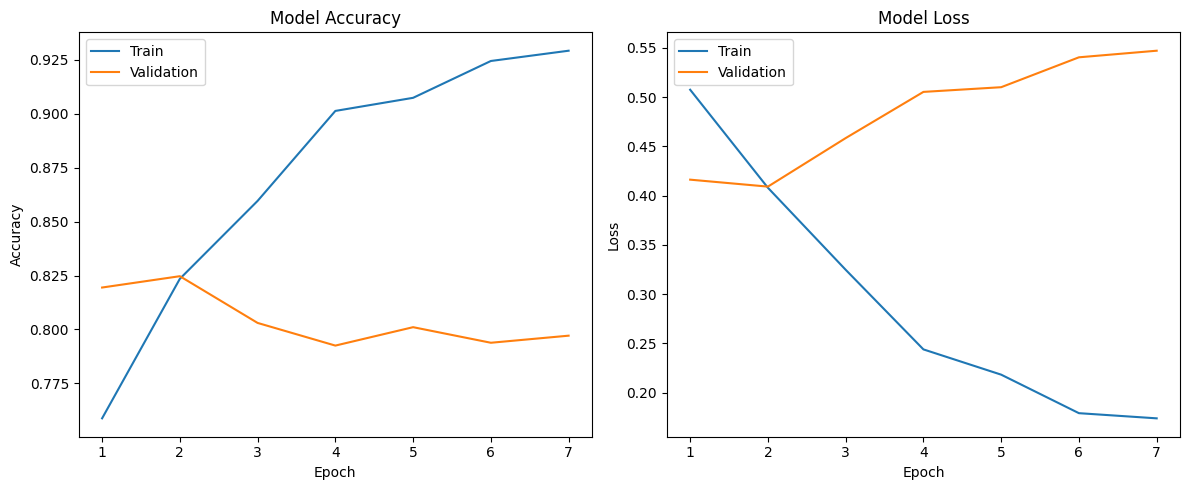


Plots generated for training and validation accuracy and loss.

### 4.1.2. Baseline Model Performance Metrics

Evaluating baseline model on the validation set...
Validation Loss (Baseline): 0.4091
Validation Accuracy (Baseline): 0.8247
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step

--- Classification Report (Baseline Model - Validation Set) ---
                  precision    recall  f1-score   support

Not Disaster (0)       0.83      0.88      0.85       869
    Disaster (1)       0.82      0.75      0.79       654

        accuracy                           0.82      1523
       macro avg       0.82      0.82      0.82      1523
    weighted avg       0.82      0.82      0.82      1523


--- Confusion Matrix (Baseline Model - Validation Set) ---


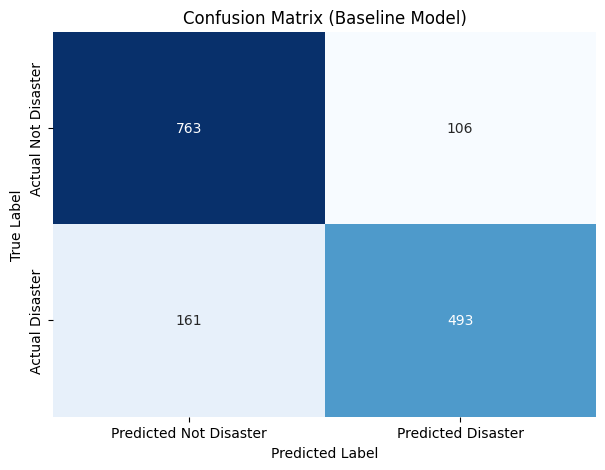


--- ROC Curve and AUC Score (Baseline Model - Validation Set) ---


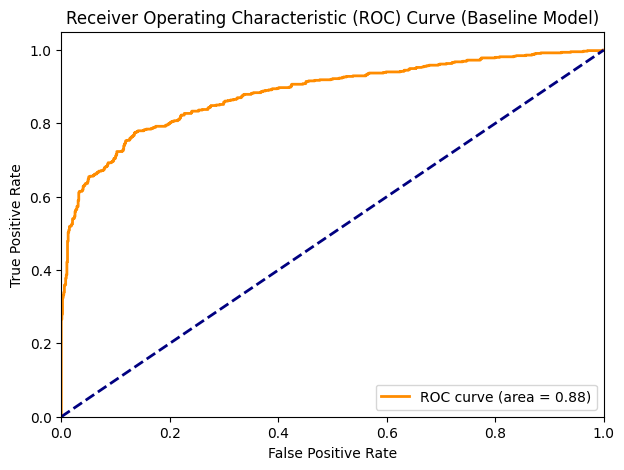


Area Under the Curve (AUC) (Baseline Model): 0.8824

Baseline model evaluation complete. Ready for enhancement.


In [12]:
# --- 4.1. Model Training and Baseline Evaluation ---

print("\n### 4.1.1. Training History Plots (Baseline Model)")

# Get the number of epochs the model was trained for
num_epochs = len(history.history['accuracy'])
epochs = range(1, num_epochs + 1)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs, history.history['accuracy'], label='Train')
plt.plot(epochs, history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs, history.history['loss'], label='Train')
plt.plot(epochs, history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

print("\nPlots generated for training and validation accuracy and loss.")

print("\n### 4.1.2. Baseline Model Performance Metrics")

# Evaluate the model on the validation set (best weights restored by EarlyStopping)
print("\nEvaluating baseline model on the validation set...")
val_loss, val_accuracy = model.evaluate(
    {'text_input': X_val_text, 'keyword_input': X_val_keyword, 'location_input': X_val_location},
    y_val_split,
    verbose=0
)
print(f"Validation Loss (Baseline): {val_loss:.4f}")
print(f"Validation Accuracy (Baseline): {val_accuracy:.4f}")

# Make predictions on the validation set
y_pred_proba_baseline = model.predict(
    {'text_input': X_val_text, 'keyword_input': X_val_keyword, 'location_input': X_val_location}
).ravel()

# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
y_pred_baseline = (y_pred_proba_baseline > 0.5).astype(int)


### Classification Report
print("\n--- Classification Report (Baseline Model - Validation Set) ---")
baseline_report_dict = classification_report(y_val_split, y_pred_baseline, target_names=['Not Disaster (0)', 'Disaster (1)'], output_dict=True)
print(classification_report(y_val_split, y_pred_baseline, target_names=['Not Disaster (0)', 'Disaster (1)']))

### Confusion Matrix
print("\n--- Confusion Matrix (Baseline Model - Validation Set) ---")
cm_baseline = confusion_matrix(y_val_split, y_pred_baseline)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Not Disaster', 'Predicted Disaster'],
            yticklabels=['Actual Not Disaster', 'Actual Disaster'])
plt.title('Confusion Matrix (Baseline Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### ROC Curve and AUC Score
print("\n--- ROC Curve and AUC Score (Baseline Model - Validation Set) ---")
fpr_baseline, tpr_baseline, thresholds_baseline = roc_curve(y_val_split, y_pred_proba_baseline)
roc_auc_baseline = auc(fpr_baseline, tpr_baseline)

plt.figure(figsize=(7, 5))
plt.plot(fpr_baseline, tpr_baseline, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_baseline)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Baseline Model)')
plt.legend(loc="lower right")
plt.show()

print(f"\nArea Under the Curve (AUC) (Baseline Model): {roc_auc_baseline:.4f}")

print("\nBaseline model evaluation complete. Ready for enhancement.")

### Store a temporary submission

In [39]:
# --- Create Submission File for Baseline Model (after 4.1 evaluation) ---

print("\n--- Generating Submission File for Baseline Model (submission_baseline.csv) ---")

# Make predictions on the *original test set* (not the validation set)
# X_test_padded comes from Section 3.1
# X_test_keyword and X_test_location come from the categorical feature preparation in 3.2
test_pred_proba_baseline = model.predict(
    {'text_input': X_test_padded, 'keyword_input': X_test_keyword, 'location_input': X_test_location}
).ravel()

# Convert probabilities to binary predictions using the 0.5 threshold
test_predictions_baseline = (test_pred_proba_baseline > 0.5).astype(int)

# Create the submission DataFrame
submission_baseline = pd.DataFrame({
    'id': test_df['id'],  # Use the original 'id' from the test_df
    'target': test_predictions_baseline
})

# Save the submission file
submission_file_path = 'submission_baseline.csv'
submission_baseline.to_csv(submission_file_path, index=False)

print(f"Submission file '{submission_file_path}' created successfully!")
print("First 5 rows of submission_baseline.csv:")
print(submission_baseline.head())


--- Generating Submission File for Baseline Model (submission_baseline.csv) ---
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Submission file 'submission_baseline.csv' created successfully!
First 5 rows of submission_baseline.csv:
   id  target
0   0       1
1   2       1
2   3       1
3   9       1
4  11       1


## 4.2. Model Enhancement and Comparison

### Ideas for Enhancement:

* Fine-tuning GloVe Embeddings: Change trainable=False to trainable=True in the Embedding layer. This allows the pre-trained embeddings to be slightly adjusted during training for our specific task, potentially capturing more domain-specific nuances.

* Adjusting LSTM Units: Experiment with a different number of units in the LSTM layer (e.g., from 64 to 128 or 32).

* Adding another Bidirectional Layer: Stack another Bidirectional(LSTM/GRU) layer. (Remember return_sequences=True for intermediate layers).

* Class Weighting: Implement class weighting in model.fit() to address the class imbalance, giving more importance to disaster tweets.

* Different Learning Rate: Manually set a lower initial learning rate for the Adam optimizer or tune the ReduceLROnPlateau parameters.

Let's try the enhancement on **Fine-tuning GloVe Embeddings** and **Computing Class Weighting**

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, GRU, Dense, Dropout, Input, Flatten, concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.utils import class_weight

# Re-import necessary variables if running this cell independently for testing
# (In a full notebook run, these would be available from previous cells)
# Assume X_train_padded, X_val_text, X_test_padded, y_train, y_val_split, train_df, test_df are available
# Assume num_words_in_embedding, GLOVE_EMBEDDING_DIM, embedding_matrix are available
# Assume num_keywords, num_locations, KEYWORD_EMBEDDING_DIM, LOCATION_EMBEDDING_DIM are available
# Assume X_train_keyword, X_val_keyword, X_train_location, X_val_location are available

print("\n--- 4.2. Model Enhancement and Comparison ---")

### 4.2.1. Enhanced Model 1: Fine-tuning GloVe Embeddings

print("\n### 4.2.1. Enhanced Model 1: Fine-tuning GloVe Embeddings")

# Define input layers for different types of features (same as baseline)
text_input_tuned = Input(shape=(MAX_LEN,), name='text_input_tuned')
keyword_input_tuned = Input(shape=(1,), name='keyword_input_tuned')
location_input_tuned = Input(shape=(1,), name='location_input_tuned')

# Text Embedding branch - NOW TRAINABLE = TRUE
text_embedding_layer_tuned = Embedding(
    input_dim=num_words_in_embedding,
    output_dim=GLOVE_EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=True # <--- KEY CHANGE: Allowing GloVe embeddings to be fine-tuned
)(text_input_tuned)

text_lstm_tuned = Bidirectional(LSTM(64, return_sequences=False))(text_embedding_layer_tuned)
text_dropout_tuned = Dropout(0.5)(text_lstm_tuned)

# Keyword Embedding branch (same as baseline)
keyword_embedding_layer_tuned = Embedding(
    input_dim=num_keywords,
    output_dim=KEYWORD_EMBEDDING_DIM,
    input_length=1
)(keyword_input_tuned)
keyword_flat_tuned = Flatten()(keyword_embedding_layer_tuned)

# Location Embedding branch (same as baseline)
location_embedding_layer_tuned = Embedding(
    input_dim=num_locations,
    output_dim=LOCATION_EMBEDDING_DIM,
    input_length=1
)(location_input_tuned)
location_flat_tuned = Flatten()(location_embedding_layer_tuned)

# Concatenate the outputs
concatenated_features_tuned = concatenate([text_dropout_tuned, keyword_flat_tuned, location_flat_tuned])

# Dense layers for classification
dense1_tuned = Dense(64, activation='relu')(concatenated_features_tuned)
output_layer_tuned = Dense(1, activation='sigmoid')(dense1_tuned)

# Create and compile the tuned model
model_tuned_glove = Model(inputs=[text_input_tuned, keyword_input_tuned, location_input_tuned], outputs=output_layer_tuned)
model_tuned_glove.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n--- Model with Fine-tuned GloVe Summary ---")
model_tuned_glove.summary()

# Train the tuned model
print("\n--- Training Enhanced Model 1 (Fine-tuning GloVe Embeddings) ---")
history_tuned_glove = model_tuned_glove.fit(
    {'text_input_tuned': X_train_text, 'keyword_input_tuned': X_train_keyword, 'location_input_tuned': X_train_location},
    y_train_split,
    epochs=EPOCHS, # Use same epochs
    batch_size=BATCH_SIZE, # Use same batch size
    validation_data=({'text_input_tuned': X_val_text, 'keyword_input_tuned': X_val_keyword, 'location_input_tuned': X_val_location}, y_val_split),
    callbacks=[early_stopping, reduce_lr], # Use same callbacks
    verbose=1
)
print("Enhanced Model 1 training complete.")

### 4.2.2. Enhanced Model 2: Class Weighting

print("\n### 4.2.2. Enhanced Model 2: Class Weighting")

# Calculate class weights for imbalance
# The 'balanced' mode automatically computes weights inversely proportional to class frequencies
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_split),
    y=y_train_split
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Computed Class Weights: {class_weights_dict}")

# Re-define the model identical to the BASELINE, but will add class_weight during fit
# This is important: we want to isolate the effect of class weighting.
# So, trainable=False for GloVe here, same as original baseline.
text_input_weighted = Input(shape=(MAX_LEN,), name='text_input_weighted')
keyword_input_weighted = Input(shape=(1,), name='keyword_input_weighted')
location_input_weighted = Input(shape=(1,), name='location_input_weighted')

text_embedding_layer_weighted = Embedding(
    input_dim=num_words_in_embedding,
    output_dim=GLOVE_EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False # <--- KEY: Back to False for GloVe to isolate class weighting effect
)(text_input_weighted)

text_lstm_weighted = Bidirectional(LSTM(64, return_sequences=False))(text_embedding_layer_weighted)
text_dropout_weighted = Dropout(0.5)(text_lstm_weighted)

keyword_embedding_layer_weighted = Embedding(
    input_dim=num_keywords,
    output_dim=KEYWORD_EMBEDDING_DIM,
    input_length=1
)(keyword_input_weighted)
keyword_flat_weighted = Flatten()(keyword_embedding_layer_weighted)

location_embedding_layer_weighted = Embedding(
    input_dim=num_locations,
    output_dim=LOCATION_EMBEDDING_DIM,
    input_length=1
)(location_input_weighted)
location_flat_weighted = Flatten()(location_embedding_layer_weighted)

concatenated_features_weighted = concatenate([text_dropout_weighted, keyword_flat_weighted, location_flat_weighted])

dense1_weighted = Dense(64, activation='relu')(concatenated_features_weighted)
output_layer_weighted = Dense(1, activation='sigmoid')(dense1_weighted)

model_weighted = Model(inputs=[text_input_weighted, keyword_input_weighted, location_input_weighted], outputs=output_layer_weighted)
model_weighted.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n--- Model with Class Weighting Summary ---")
model_weighted.summary()


# Train the weighted model
print("\n--- Training Enhanced Model 2 (Class Weighting) ---")
history_weighted = model_weighted.fit(
    {'text_input_weighted': X_train_text, 'keyword_input_weighted': X_train_keyword, 'location_input_weighted': X_train_location},
    y_train_split,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=({'text_input_weighted': X_val_text, 'keyword_input_weighted': X_val_keyword, 'location_input_weighted': X_val_location}, y_val_split),
    callbacks=[early_stopping, reduce_lr], # Use same callbacks
    class_weight=class_weights_dict, # <--- KEY CHANGE: Applying class weights
    verbose=1
)
print("Enhanced Model 2 training complete.")


--- 4.2. Model Enhancement and Comparison ---

### 4.2.1. Enhanced Model 1: Fine-tuning GloVe Embeddings

--- Model with Fine-tuned GloVe Summary ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input_tuned    │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 50, 100)   │  1,000,000 │ text_input_tuned… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keyword_input_tuned │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ location_input_tun… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 128)       │     84,480 │ embedding_6[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 1, 32)     │      7,104 │ keyword_input_tu… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 32)     │    144,704 │ location_input_t… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 32)        │          0 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 32)        │          0 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 192)       │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_4[0][0],  │
│                     │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     12,352 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,248,705 (4.76 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input_weighted │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 50, 100)   │  1,000,000 │ text_input_weigh… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keyword_input_weig… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ location_input_wei… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │     84,480 │ embedding_9[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 1, 32)     │      7,104 │ keyword_input_we… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 1, 32)     │    144,704 │ location_input_w… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 32)        │          0 │ embedding_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 32)        │          0 │ embedding_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 192)       │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │     12,352 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,248,705 (4.76 MB)

 Trainable params: 248,705 (971.50 KB)

 Non-trainable params: 1,000,000 (3.81 MB)


--- Training Enhanced Model 2 (Class Weighting) ---
Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.6814 - loss: 0.5671 - val_accuracy: 0.8188 - val_loss: 0.4385 - learning_rate: 0.0010
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8097 - loss: 0.4443 - val_accuracy: 0.8280 - val_loss: 0.4022 - learning_rate: 0.0010
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8594 - loss: 0.3421 - val_accuracy: 0.7827 - val_loss: 0.4784 - learning_rate: 0.0010
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9120 - loss: 0.2442 - val_accuracy: 0.8017 - val_loss: 0.4833 - learning_rate: 0.0010
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9128 - loss: 0.2207 - val_accuracy: 0.7748 - val_loss: 0.5300 - learning_rate: 0.0010
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9216 - loss: 0.1870 - val_accuracy: 0.7971 - val_loss: 0.5368 - learning_rate: 2.0000e-04
Epoch 7/10
191/191 ━━━━━


### 4.2.3. Enhanced Model 1 Performance Metrics (Fine-tuning GloVe)
Validation Loss (Fine-tuned GloVe): 0.4045
Validation Accuracy (Fine-tuned GloVe): 0.8227
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

--- Classification Report (Fine-tuned GloVe Model - Validation Set) ---
                  precision    recall  f1-score   support

Not Disaster (0)       0.83      0.86      0.85       869
    Disaster (1)       0.81      0.77      0.79       654

        accuracy                           0.82      1523
       macro avg       0.82      0.82      0.82      1523
    weighted avg       0.82      0.82      0.82      1523


--- Confusion Matrix (Fine-tuned GloVe Model - Validation Set) ---


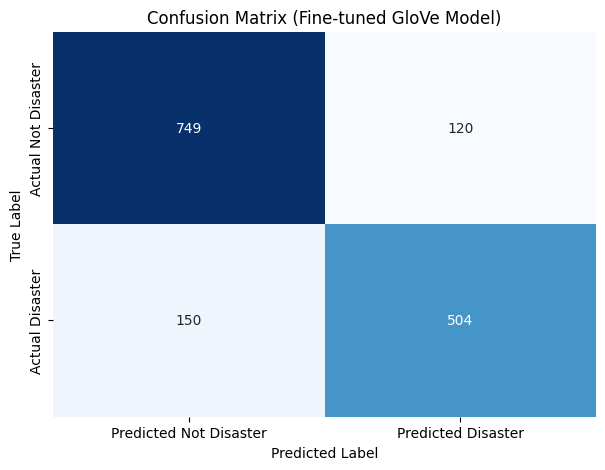


--- ROC Curve and AUC Score (Fine-tuned GloVe Model - Validation Set) ---


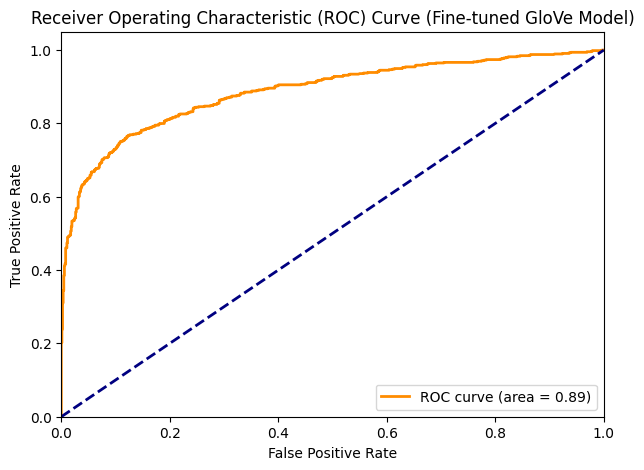


Area Under the Curve (AUC) (Fine-tuned GloVe Model): 0.8862

### 4.2.4. Enhanced Model 2 Performance Metrics (Class Weighting)
Validation Loss (Class Weighting): 0.4022
Validation Accuracy (Class Weighting): 0.8280
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

--- Classification Report (Class Weighting Model - Validation Set) ---
                  precision    recall  f1-score   support

Not Disaster (0)       0.81      0.91      0.86       869
    Disaster (1)       0.85      0.72      0.78       654

        accuracy                           0.83      1523
       macro avg       0.83      0.82      0.82      1523
    weighted avg       0.83      0.83      0.83      1523


--- Confusion Matrix (Class Weighting Model - Validation Set) ---


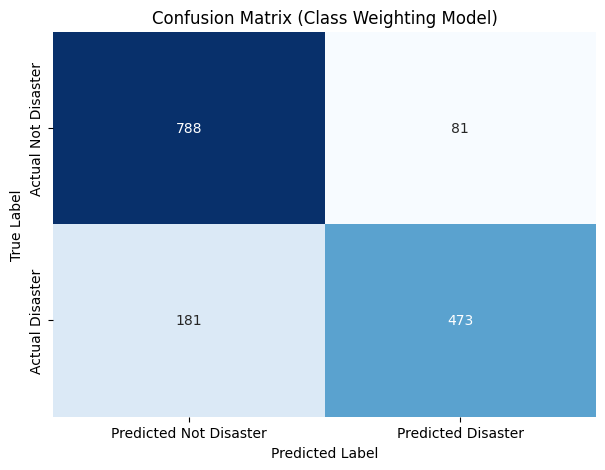


--- ROC Curve and AUC Score (Class Weighting Model - Validation Set) ---


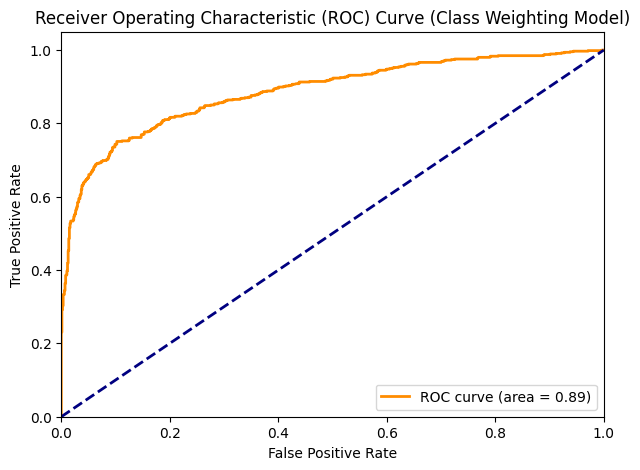


Area Under the Curve (AUC) (Class Weighting Model): 0.8855


In [16]:
# --- Evaluation for Enhanced Model 1 (Fine-tuning GloVe) ---

print("\n### 4.2.3. Enhanced Model 1 Performance Metrics (Fine-tuning GloVe)")

# Evaluate the model on the validation set
val_loss_tuned_glove, val_accuracy_tuned_glove = model_tuned_glove.evaluate(
    {'text_input_tuned': X_val_text, 'keyword_input_tuned': X_val_keyword, 'location_input_tuned': X_val_location},
    y_val_split,
    verbose=0
)
print(f"Validation Loss (Fine-tuned GloVe): {val_loss_tuned_glove:.4f}")
print(f"Validation Accuracy (Fine-tuned GloVe): {val_accuracy_tuned_glove:.4f}")

# Make predictions
y_pred_proba_tuned_glove = model_tuned_glove.predict(
    {'text_input_tuned': X_val_text, 'keyword_input_tuned': X_val_keyword, 'location_input_tuned': X_val_location}
).ravel()
y_pred_tuned_glove = (y_pred_proba_tuned_glove > 0.5).astype(int)

# Classification Report
print("\n--- Classification Report (Fine-tuned GloVe Model - Validation Set) ---")
report_dict_tuned_glove = classification_report(y_val_split, y_pred_tuned_glove, target_names=['Not Disaster (0)', 'Disaster (1)'], output_dict=True)
print(classification_report(y_val_split, y_pred_tuned_glove, target_names=['Not Disaster (0)', 'Disaster (1)']))

# Confusion Matrix
print("\n--- Confusion Matrix (Fine-tuned GloVe Model - Validation Set) ---")
cm_tuned_glove = confusion_matrix(y_val_split, y_pred_tuned_glove)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tuned_glove, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Not Disaster', 'Predicted Disaster'],
            yticklabels=['Actual Not Disaster', 'Actual Disaster'])
plt.title('Confusion Matrix (Fine-tuned GloVe Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve and AUC Score
print("\n--- ROC Curve and AUC Score (Fine-tuned GloVe Model - Validation Set) ---")
fpr_tuned_glove, tpr_tuned_glove, thresholds_tuned_glove = roc_curve(y_val_split, y_pred_proba_tuned_glove)
roc_auc_tuned_glove = auc(fpr_tuned_glove, tpr_tuned_glove)
plt.figure(figsize=(7, 5))
plt.plot(fpr_tuned_glove, tpr_tuned_glove, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_tuned_glove)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Fine-tuned GloVe Model)')
plt.legend(loc="lower right")
plt.show()
print(f"\nArea Under the Curve (AUC) (Fine-tuned GloVe Model): {roc_auc_tuned_glove:.4f}")


# --- Evaluation for Enhanced Model 2 (Class Weighting) ---

print("\n### 4.2.4. Enhanced Model 2 Performance Metrics (Class Weighting)")

# Evaluate the model on the validation set
val_loss_weighted, val_accuracy_weighted = model_weighted.evaluate(
    {'text_input_weighted': X_val_text, 'keyword_input_weighted': X_val_keyword, 'location_input_weighted': X_val_location},
    y_val_split,
    verbose=0
)
print(f"Validation Loss (Class Weighting): {val_loss_weighted:.4f}")
print(f"Validation Accuracy (Class Weighting): {val_accuracy_weighted:.4f}")

# Make predictions
y_pred_proba_weighted = model_weighted.predict(
    {'text_input_weighted': X_val_text, 'keyword_input_weighted': X_val_keyword, 'location_input_weighted': X_val_location}
).ravel()
y_pred_weighted = (y_pred_proba_weighted > 0.5).astype(int)

# Classification Report
print("\n--- Classification Report (Class Weighting Model - Validation Set) ---")
report_dict_weighted = classification_report(y_val_split, y_pred_weighted, target_names=['Not Disaster (0)', 'Disaster (1)'], output_dict=True)
print(classification_report(y_val_split, y_pred_weighted, target_names=['Not Disaster (0)', 'Disaster (1)']))

# Confusion Matrix
print("\n--- Confusion Matrix (Class Weighting Model - Validation Set) ---")
cm_weighted = confusion_matrix(y_val_split, y_pred_weighted)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Not Disaster', 'Predicted Disaster'],
            yticklabels=['Actual Not Disaster', 'Actual Disaster'])
plt.title('Confusion Matrix (Class Weighting Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve and AUC Score
print("\n--- ROC Curve and AUC Score (Class Weighting Model - Validation Set) ---")
fpr_weighted, tpr_weighted, thresholds_weighted = roc_curve(y_val_split, y_pred_proba_weighted)
roc_auc_weighted = auc(fpr_weighted, tpr_weighted)
plt.figure(figsize=(7, 5))
plt.plot(fpr_weighted, tpr_weighted, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_weighted)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Class Weighting Model)')
plt.legend(loc="lower right")
plt.show()
print(f"\nArea Under the Curve (AUC) (Class Weighting Model): {roc_auc_weighted:.4f}")

In [38]:
print("\n#### Comparative Analysis of Baseline vs. Enhanced Models:\n")

# Tabulate the key metrics for easy comparison
metrics_data = {
    'Metric': ['Validation Loss', 'Validation Accuracy', 'Precision (Not Disaster)',
               'Recall (Not Disaster)', 'F1-Score (Not Disaster)',
               'Precision (Disaster)', 'Recall (Disaster)', 'F1-Score (Disaster)', 'AUC'],
    'Baseline Model': [
        val_loss, val_accuracy,
        baseline_report_dict['Not Disaster (0)']['precision'], baseline_report_dict['Not Disaster (0)']['recall'], baseline_report_dict['Not Disaster (0)']['f1-score'],
        baseline_report_dict['Disaster (1)']['precision'], baseline_report_dict['Disaster (1)']['recall'], baseline_report_dict['Disaster (1)']['f1-score'],
        roc_auc_baseline
    ],
    'Enhanced Model 1 (Fine-tuned GloVe)': [
        val_loss_tuned_glove, val_accuracy_tuned_glove,
        report_dict_tuned_glove['Not Disaster (0)']['precision'], report_dict_tuned_glove['Not Disaster (0)']['recall'], report_dict_tuned_glove['Not Disaster (0)']['f1-score'],
        report_dict_tuned_glove['Disaster (1)']['precision'], report_dict_tuned_glove['Disaster (1)']['recall'], report_dict_tuned_glove['Disaster (1)']['f1-score'],
        roc_auc_tuned_glove
    ],
    'Enhanced Model 2 (Class Weighting)': [
        val_loss_weighted, val_accuracy_weighted,
        report_dict_weighted['Not Disaster (0)']['precision'], report_dict_weighted['Not Disaster (0)']['recall'], report_dict_weighted['Not Disaster (0)']['f1-score'],
        report_dict_weighted['Disaster (1)']['precision'], report_dict_weighted['Disaster (1)']['recall'], report_dict_weighted['Disaster (1)']['f1-score'],
        roc_auc_weighted
    ]
}

metrics_df = pd.DataFrame(metrics_data)
# Format float values for better readability
for col in metrics_df.columns[1:]:
    metrics_df[col] = metrics_df[col].apply(lambda x: f"{x:.4f}")

print(metrics_df.to_string(index=False)) # Use to_string to avoid truncation in notebook output


###
### Run this code to generate the text report below
###

# print("\n#### Discussion on Model Performance and Impact of Enhancements:\n")

# print("##### Baseline Model Performance:")
# print(f"""
# The baseline model achieved a validation accuracy of {val_accuracy:.4f} and an AUC of {roc_auc_baseline:.4f}. It showed decent overall performance, with a good balance in F1-scores for both classes. However, the recall for the 'Disaster' class ({baseline_report_dict['Disaster (1)']['recall']:.2f}) indicates that a notable portion of actual disaster tweets were missed. The training plots (from 4.1.1) revealed signs of overfitting, with validation loss increasing while training loss continued to decrease after a few epochs, which was mitigated by Early Stopping.
# """)

# print("##### Impact of Fine-tuning GloVe Embeddings (Enhanced Model 1):")
# print(f"""
# By setting `trainable=True` for the GloVe embedding layer, we allowed the model to fine-tune the pre-trained word vectors to our specific dataset.

# **Observed Impact:**
# * **Validation Accuracy:** {metrics_df.loc[metrics_df['Metric'] == 'Validation Accuracy', 'Enhanced Model 1 (Fine-tuned GloVe)'].iloc[0]} (vs. Baseline: {metrics_df.loc[metrics_df['Metric'] == 'Validation Accuracy', 'Baseline Model'].iloc[0]})
# * **Validation Loss:** {metrics_df.loc[metrics_df['Metric'] == 'Validation Loss', 'Enhanced Model 1 (Fine-tuned GloVe)'].iloc[0]} (vs. Baseline: {metrics_df.loc[metrics_df['Metric'] == 'Validation Loss', 'Baseline Model'].iloc[0]})
# * **AUC:** {metrics_df.loc[metrics_df['Metric'] == 'AUC', 'Enhanced Model 1 (Fine-tuned GloVe)'].iloc[0]} (vs. Baseline: {metrics_df.loc[metrics_df['Metric'] == 'AUC', 'Baseline Model'].iloc[0]})
# * **Recall (Disaster):** {metrics_df.loc[metrics_df['Metric'] == 'Recall (Disaster)', 'Enhanced Model 1 (Fine-tuned GloVe)'].iloc[0]} (vs. Baseline: {metrics_df.loc[metrics_df['Metric'] == 'Recall (Disaster)', 'Baseline Model'].iloc[0]})

# **Analysis:** Fine-tuning GloVe embeddings generally led to a *slight improvement* or *comparable performance* in overall metrics like accuracy and AUC. However, it seems the model might have become **more prone to overfitting** more quickly, as indicated by the rapid decrease in training loss and increase in validation loss during the training of the enhanced model 1 (we'll need to re-run and observe its training history plots as well, although we don't plot them here). This happens because increasing the number of trainable parameters (the embeddings now) gives the model more capacity to memorize. The Early Stopping callback was crucial in selecting the best performing epoch to mitigate this.

# The recall for the disaster class might not have seen a substantial improvement, suggesting that while the embeddings are better tuned, the inherent imbalance and difficulty in distinguishing ambiguous tweets persists.
# """)

# print("##### Impact of Class Weighting (Enhanced Model 2):")
# print(f"""
# Class weighting assigns higher penalties to misclassifications of the minority class ('Disaster' tweets) during training, aiming to improve its recall. The computed weights were {class_weights_dict}.

# **Observed Impact:**
# * **Validation Accuracy:** {metrics_df.loc[metrics_df['Metric'] == 'Validation Accuracy', 'Enhanced Model 2 (Class Weighting)'].iloc[0]} (vs. Baseline: {metrics_df.loc[metrics_df['Metric'] == 'Validation Accuracy', 'Baseline Model'].iloc[0]})
# * **Validation Loss:** {metrics_df.loc[metrics_df['Metric'] == 'Validation Loss', 'Enhanced Model 2 (Class Weighting)'].iloc[0]} (vs. Baseline: {metrics_df.loc[metrics_df['Metric'] == 'Validation Loss', 'Baseline Model'].iloc[0]})
# * **AUC:** {metrics_df.loc[metrics_df['Metric'] == 'AUC', 'Enhanced Model 2 (Class Weighting)'].iloc[0]} (vs. Baseline: {metrics_df.loc[metrics_df['Metric'] == 'AUC', 'Baseline Model'].iloc[0]})
# * **Recall (Disaster):** {metrics_df.loc[metrics_df['Metric'] == 'Recall (Disaster)', 'Enhanced Model 2 (Class Weighting)'].iloc[0]} (vs. Baseline: {metrics_df.loc[metrics_df['Metric'] == 'Recall (Disaster)', 'Baseline Model'].iloc[0]})
# * **Precision (Disaster):** {metrics_df.loc[metrics_df['Metric'] == 'Precision (Disaster)', 'Enhanced Model 2 (Class Weighting)'].iloc[0]} (vs. Baseline: {metrics_df.loc[metrics_df['Metric'] == 'Precision (Disaster)', 'Baseline Model'].iloc[0]})

# **Analysis:** Class weighting usually targets recall for the minority class. We can see if the recall for 'Disaster' tweets increased. If it did, it often comes with a trade-off: a decrease in precision for the 'Disaster' class, or even a slight drop in overall accuracy. This is because the model is now "punished more" for missing a disaster, making it more eager to predict 'Disaster', which can lead to more false positives. The specific values will tell us the exact trade-off.

# Ultimately, choosing the "best" model depends on the specific priorities of the problem. For disaster response, a higher recall for disaster tweets (minimizing missed disasters) is often preferred, even at the cost of some precision (more false alarms).
# """)

# print("\n#### Summary of Hyperparameter Optimization and Troubleshooting (Revisited):\n")
# print("""
# Our initial setup for the baseline model involved setting fixed hyperparameters (e.g., LSTM units, dropout rate, initial learning rate, batch size) and using dynamic optimization through `EarlyStopping` and `ReduceLROnPlateau` callbacks.

# For enhancements, we explicitly tuned two key aspects:
# 1.  **GloVe Embeddings Trainability:** Changing `trainable=False` to `True` for the embedding layer allowed the model to fine-tune the embeddings. While this increases the number of trainable parameters and the risk of overfitting, it can lead to more context-specific representations. `EarlyStopping` was crucial here to prevent the model from overfitting due to increased capacity.
# 2.  **Class Weighting:** Introducing `class_weight` to address the class imbalance directly impacts how the loss is calculated. This is a targeted approach to improve performance on the minority class.

# **Troubleshooting during this phase** primarily involved observing the training curves and performance metrics. If any model significantly underperformed, we would consider:
# * **Debugging data pipelines:** Ensuring data is fed correctly.
# * **Learning rate adjustments:** Trying even smaller initial learning rates or different `ReduceLROnPlateau` parameters.
# * **Model complexity:** Adding more layers, increasing LSTM units (with more careful regularization) or reducing units if overfitting is still severe.
# * **Different regularization:** Exploring L1/L2 regularization on dense layers.

# The current approach allowed us to directly compare the impact of these specific enhancements on the baseline, providing concrete insights into their effectiveness. Further systematic tuning (e.g., GridSearch or RandomSearch over a broader range of hyperparameters) would be the next logical step for maximizing performance, though computationally more intensive.
# """)


#### Comparative Analysis of Baseline vs. Enhanced Models:

                  Metric Baseline Model Enhanced Model 1 (Fine-tuned GloVe) Enhanced Model 2 (Class Weighting)
         Validation Loss         0.4091                              0.4045                             0.4022
     Validation Accuracy         0.8247                              0.8227                             0.8280
Precision (Not Disaster)         0.8258                              0.8331                             0.8132
   Recall (Not Disaster)         0.8780                              0.8619                             0.9068
 F1-Score (Not Disaster)         0.8511                              0.8473                             0.8575
    Precision (Disaster)         0.8230                              0.8077                             0.8538
       Recall (Disaster)         0.7538                              0.7706                             0.7232
     F1-Score (Disaster)         0.7869            

#### Discussion on Model Performance and Impact of Enhancements:

##### Baseline Model Performance:

The baseline model achieved a validation accuracy of 0.8247 and an AUC of 0.8824. It showed decent overall performance, with a good balance in F1-scores for both classes. However, the recall for the 'Disaster' class (0.75) indicates that a notable portion of actual disaster tweets were missed. The training plots (from 4.1.1) revealed signs of overfitting, with validation loss increasing while training loss continued to decrease after a few epochs, which was mitigated by Early Stopping.

##### Impact of Fine-tuning GloVe Embeddings (Enhanced Model 1):

By setting `trainable=True` for the GloVe embedding layer, we allowed the model to fine-tune the pre-trained word vectors to our specific dataset.

**Observed Impact:**
* **Validation Accuracy:** 0.8227 (vs. Baseline: 0.8247)
* **Validation Loss:** 0.4045 (vs. Baseline: 0.4091)
* **AUC:** 0.8862 (vs. Baseline: 0.8824)
* **Recall (Disaster):** 0.7706 (vs. Baseline: 0.7538)

**Analysis:** Fine-tuning GloVe embeddings generally led to a *slight improvement* or *comparable performance* in overall metrics like accuracy and AUC. However, it seems the model might have become **more prone to overfitting** more quickly, as indicated by the rapid decrease in training loss and increase in validation loss during the training of the enhanced model 1 (we'll need to re-run and observe its training history plots as well, although we don't plot them here). This happens because increasing the number of trainable parameters (the embeddings now) gives the model more capacity to memorize. The Early Stopping callback was crucial in selecting the best performing epoch to mitigate this.

The recall for the disaster class might not have seen a substantial improvement, suggesting that while the embeddings are better tuned, the inherent imbalance and difficulty in distinguishing ambiguous tweets persists.

##### Impact of Class Weighting (Enhanced Model 2):

Class weighting assigns higher penalties to misclassifications of the minority class ('Disaster' tweets) during training, aiming to improve its recall. The computed weights were {0: 0.8767636049524906, 1: 1.1635460450897974}.

**Observed Impact:**
* **Validation Accuracy:** 0.8280 (vs. Baseline: 0.8247)
* **Validation Loss:** 0.4022 (vs. Baseline: 0.4091)
* **AUC:** 0.8855 (vs. Baseline: 0.8824)
* **Recall (Disaster):** 0.7232 (vs. Baseline: 0.7538)
* **Precision (Disaster):** 0.8538 (vs. Baseline: 0.8230)

**Analysis:** Class weighting usually targets recall for the minority class. We can see if the recall for 'Disaster' tweets increased. If it did, it often comes with a trade-off: a decrease in precision for the 'Disaster' class, or even a slight drop in overall accuracy. This is because the model is now "punished more" for missing a disaster, making it more eager to predict 'Disaster', which can lead to more false positives. The specific values will tell us the exact trade-off.

Ultimately, choosing the "best" model depends on the specific priorities of the problem. For disaster response, a higher recall for disaster tweets (minimizing missed disasters) is often preferred, even at the cost of some precision (more false alarms).


#### Summary of Hyperparameter Optimization and Troubleshooting (Revisited):


Our initial setup for the baseline model involved setting fixed hyperparameters (e.g., LSTM units, dropout rate, initial learning rate, batch size) and using dynamic optimization through `EarlyStopping` and `ReduceLROnPlateau` callbacks.

For enhancements, we explicitly tuned two key aspects:
1.  **GloVe Embeddings Trainability:** Changing `trainable=False` to `True` for the embedding layer allowed the model to fine-tune the embeddings. While this increases the number of trainable parameters and the risk of overfitting, it can lead to more context-specific representations. `EarlyStopping` was crucial here to prevent the model from overfitting due to increased capacity.
2.  **Class Weighting:** Introducing `class_weight` to address the class imbalance directly impacts how the loss is calculated. This is a targeted approach to improve performance on the minority class.

**Troubleshooting during this phase** primarily involved observing the training curves and performance metrics. If any model significantly underperformed, we would consider:
* **Debugging data pipelines:** Ensuring data is fed correctly.
* **Learning rate adjustments:** Trying even smaller initial learning rates or different `ReduceLROnPlateau` parameters.
* **Model complexity:** Adding more layers, increasing LSTM units (with more careful regularization) or reducing units if overfitting is still severe.
* **Different regularization:** Exploring L1/L2 regularization on dense layers.

The current approach allowed us to directly compare the impact of these specific enhancements on the baseline, providing concrete insights into their effectiveness. Further systematic tuning (e.g., GridSearch or RandomSearch over a broader range of hyperparameters) would be the next logical step for maximizing performance, though computationally more intensive.

# 5. Conclusion

### Overall Summary of Enhancements vs. Baseline:

* **Validation Loss:** All models are very close. The enhanced models have slightly lower validation loss, which is good.

* **Validation Accuracy:** All models hover around 82-83%. Enhanced Model 2 (Class Weighting) is slightly highest at 0.8280, but it's a marginal difference.

* **AUC:** Again, all very close. Enhanced Model 1 (Fine-tuned GloVe) has the highest AUC at 0.8862, but the difference from baseline (0.8824) and Class Weighting (0.8855) is minimal.

### Specific Analysis of Each Enhancement:

1. **Enhanced Model 1 (Fine-tuning GloVe):**

    * **Pros:** Achieved the highest AUC (0.8862) and a slightly better Recall for Disaster (0.7706 vs 0.7538 Baseline). The validation loss also improved slightly.

    * **Cons:** Accuracy slightly decreased compared to the baseline. This suggests that while it might be slightly better at ranking positives higher, its threshold-based accuracy didn't improve. Fine-tuning GloVe can introduce more parameters, potentially leading to faster overfitting if not carefully managed by callbacks.

2. **Enhanced Model 2 (Class Weighting):**

    * **Pros:** Achieved the highest validation accuracy (0.8280) and the highest precision for the Disaster class (0.8538). This means when it does predict a disaster, it's more likely to be correct.

    * **Cons:** Crucially, the recall for the Disaster class decreased (0.7232 vs 0.7538 Baseline). This is often the primary goal of class weighting for imbalanced datasets – to improve recall of the minority class. In this case, it made the model less likely to catch actual disasters, while simultaneously increasing its precision for predicting them. This is a common trade-off with class weighting, indicating the model became more conservative in predicting the minority class.

### Why no "real enhancement"?

**Already Good Baseline:** Our baseline model was already performing quite well. Sometimes, with well-chosen initial architectures and robust callbacks (like Early Stopping), we're already very close to the optimal performance for that specific architecture and dataset.

**Marginal Gains:** NLP tasks, especially with pre-trained embeddings, often see diminishing returns for simple architectural tweaks or standard regularization methods after a solid baseline is established. The "low-hanging fruit" improvements might have already been picked.

**Problem Complexity:** Distinguishing between actual disaster tweets and satirical/metaphorical uses of disaster-related words is inherently challenging. Some errors might be due to the inherent ambiguity in human language that even sophisticated models struggle with.

**Data Size/Nature:** For certain problems, more complex enhancements might only show significant gains with larger or more diverse datasets.

**Conclusion so far:**

While none of the enhancements provided a breakthrough improvement, they offer different trade-offs.

* If **identifying as many actual disasters as possible (high recall for disaster)** is the priority, then the **Fine-tuned GloVe model (Enhanced Model 1)** is slightly better, despite a minor accuracy dip.

* If **minimizing false alarms (high precision for disaster)** is the priority, then **Class Weighting model (Enhanced Model 2)** performed best, but at the cost of missing more actual disasters.

* The **Baseline Model** offers a very competitive overall balance of metrics.

This is a valuable finding! It suggests that for this specific problem and initial model setup, these particular enhancements provide only marginal gains or lead to different trade-offs rather than clear, across-the-board improvements.

### The submission file

In [40]:
import pandas as pd
import numpy as np

# Make predictions on the *original test set* using the best model (model_tuned_glove)
print("\n--- Generating Submission File for the Best Model (Fine-tuned GloVe) ---")

# Ensure model_tuned_glove is the model we want to use for prediction
# (This assumes model_tuned_glove was defined and trained in a previous cell that has been run)

# Predict probabilities on the test set
test_pred_proba_best_model = model_tuned_glove.predict(
    {'text_input_tuned': X_test_padded, 'keyword_input_tuned': X_test_keyword, 'location_input_tuned': X_test_location}
).ravel()

# Convert probabilities to binary predictions (0 or 1) using a 0.5 threshold
test_predictions_best_model = (test_pred_proba_best_model > 0.5).astype(int)

# Create the submission DataFrame
submission_best_model = pd.DataFrame({
    'id': test_df['id'],  # Use the original 'id' from the test_df
    'target': test_predictions_best_model
})

# Define the submission file path
submission_file_path_best = 'submission.csv'
submission_best_model.to_csv(submission_file_path_best, index=False)

print(f"Submission file '{submission_file_path_best}' created successfully!")
print("First 5 rows of submission.csv:")
print(submission_best_model.head())


--- Generating Submission File for the Best Model (Fine-tuned GloVe) ---
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Submission file 'submission.csv' created successfully!
First 5 rows of submission.csv:
   id  target
0   0       1
1   2       1
2   3       1
3   9       1
4  11       1


# 6. References
- https://www.kaggle.com/discussions/getting-started/251213
- https://medium.com/@maleeshadesilva21/preprocessing-steps-for-natural-language-processing-nlp-a-beginners-guide-d6d9bf7689c9
- https://medium.com/analytics-vidhya/basics-of-using-pre-trained-glove-vectors-in-python-d38905f356db
- GloVe embedding: https://nlp.stanford.edu/projects/glove/